#  Projet de Machine Learning :  Prédiction du Top 3 en courses hippiques
Objectif : Réaliser un projet de machine learning sur un dataset de 4000 observations minimums.
Vous devez obligatoirement réaliser une régression ou classification en comparant différents modèles (SVM, Modèle linéaire, Random Forest, ...).
Vous devez également interpréter localement et globalement votre modèle de machine learning avec les méthodes vues dans la partie explicabilité et interprétabilité.

Modalités : Pour l'évaluation vous devrez me soumettre un projet comportant un fichier .md(markdown) qui contient les commentaires et résultats de votre projet. 
Présentation de vos résultats, discussion du choix des méthodes, vos analyses, ... 
Il faudra également me joindre un fichier en .py ou .ipynb avec votre code.

Tous ces éléments devront être déposés dans un repo Github à votre nom/vos noms!
Date de rendu 13-04-2026 23:59:59. 


## 1. Présentation des données
### 1.1 Source des données

Les variables : 
- date: date de la course 
- course : nom de l'hippodrome de la course  ( le lieu)
- race_id : identifiant de race   ( 184 732 d'identifiant unique donc a supp probablement)
- off: durée qu'il a mis pour faire la course
- race_name : nom précis de la course 
- type: type de course ( ex: trot, Plat, Obstacle )
- class : hiérarchie officielle du niveau des courses
- pattern: classification des courses encore plus prestigieuse que “class”
- rating_band : niveau moyen attendu des chevaux dans la course : représente une borne d’admission de la course
- age_band : tranche d’âge autorisée pour la course
- sex_rest :  contrainte indiquant si la course est réservée à un sexe particulier
- dist:  distance de la course  MAIS exprimée en format hippique UK ( la mort :))
- going : état du terrain (track condition) au moment de la course.
- ran : pas reussi a etre certaine de ce que c'est donc a supp.
- num : numéro attribué dans le programme ( pas interessant )
- pos : position finale
- draw : place dans les boîtes de départ
- ovr_btn :  distance derrière le gagnant ( a supp car fuite d'info)
- btn : distance derrière le cheval juste devant  ( a supp car fuite d'info)
- horse :  nom du cheval + pays d’origine
- age : age du cheval 
- sex : sexe du cheval en catégories fines
- wgt :  poids porté par le cheval pendant la course (en pounds (standard turf))  --> a transformer 
- hg :  headgear (équipement de tête du cheval)
- time : temps que le cheval a mis 
- sp :  Starting Price = cote finale du cheval au départ
- jockey : nom du jockey
- trainer : nnom de l'entraineur
- prize :  gain individuel du cheval dans la course ( a supp car fuite d'info)
- or : Official Rating : C’est la note officielle  (mesure la qualité intrinsèque du cheval.)
- rpr :  Racing Post Rating (note donnée par le journal spécialisé Racing Post  ) mais de la course ( a supp car fuite d'info)
- ts :  Topspeed Rating  (note également établi apres course ) ( a supp car fuite d'info)
- sire : père du cheval
- dam : mère du cheval
- damsire : père de la mère du cheval
- owner : nom du propriétaire 
- comment : commentaire sur la course ( a supp car fuite d'info)

Les variables a garder pour la suite : 
date
type
class
pattern
rating_band
age_band
sex_rest
dist
going
ran
draw
age
sex
wgt
hg
sp
or
jockey
trainer
pos --> va etre modifier en top3 


In [34]:
import sqlite3
import os


conn = sqlite3.connect("../data/raceform.db")
cursor = conn.cursor()

cursor.execute("SELECT COUNT(*) FROM data")
print(cursor.fetchone())

(1811590,)


In [87]:
import pandas as pd

df = pd.read_sql("SELECT * FROM data", conn)

print(df.shape)

(1811590, 37)


### 1.2 Exploration des données

In [88]:
pd.set_option('display.max_columns', None)
df.head()

,date,course,race_id,off,race_name,type,class,pattern,rating_band,age_band,sex_rest,dist,going,ran,num,pos,draw,ovr_btn,btn,horse,age,sex,wgt,hg,time,sp,jockey,trainer,prize,or,rpr,ts,sire,dam,damsire,owner,comment
0,date,course,race_id,off,race_name,type,class,pattern,rating_band,age_band,sex_rest,dist,going,ran,num,pos,draw,ovr_btn,btn,horse,age,sex,wgt,hg,time,sp,jockey,trainer,prize,or,rpr,ts,sire,dam,damsire,owner,comment
1,2015-01-01,Catterick,615704,12:30,Happy New Year Novices Hurdle,Hurdle,Class 4,,,4yo+,,2m3½f,Good To Soft,10,3,1,,0,0,Definitly Red (IRE),6,G,11-6,,4:50.90,1/3F,William Kennedy,Brian Ellison,4873.5,–,114,80,Definite Article (GB),The Red Wench (IRE),Aahsaylad,P J Martin,Tracked leaders - effort 3 out - led approachi...
2,2015-01-01,Tramore (IRE),616859,12:35,2015 Waterford & Tramore Racecourse Supporters...,Hurdle,,,80-109,4yo+,,2m,Heavy,8,8,PU,,-,-,Tynaghs Trooper (IRE),9,G,9-8,p,-,25/1,Andrew Ring,P J Rothwell,,81,–,–,Pyrus (USA),Lorli (IRE),Mukaddamah,Michael Cawe,Always in rear - never a factor - pulled up be...
3,2015-01-01,Tramore (IRE),616860,1:05,Padraig Curran - South East Cleaners Maiden Hu...,Hurdle,,,,5yo+,,2m5f,Heavy,8,7,1,,0,0,Sambremont (FR),5,G,11-1,,5:57.00,8/15F,R Walsh,W P Mullins,€6037.50,–,122,32,Saint Des Saints (FR),Rainbow Crest (FR),Baryshnikov,Shanakiel Racing Syndicate,Soon chased leaders in 3rd - progress to dispu...
4,2015-01-01,Tramore (IRE),616860,1:05,Padraig Curran - South East Cleaners Maiden Hu...,Hurdle,,,,5yo+,,2m5f,Heavy,8,9,2,,1.75,1.75,Perfect Woman (IRE),7,M,10-11,,5:57.35,9/2,Patrick Mangan,Michael Winters,€1400,–,116,26,Blueprint (IRE),Garrisker (IRE),Kings Ride,John J Madden,Chased leaders in 4th until took closer order ...


In [89]:
# suprimer la premier ligne
df = df.drop(0)

In [74]:
df.head()

,date,course,race_id,off,race_name,type,class,pattern,rating_band,age_band,sex_rest,dist,going,ran,num,pos,draw,ovr_btn,btn,horse,age,sex,wgt,hg,time,sp,jockey,trainer,prize,or,rpr,ts,sire,dam,damsire,owner,comment
1,2015-01-01,Catterick,615704,12:30,Happy New Year Novices Hurdle,Hurdle,Class 4,,,4yo+,,2m3½f,Good To Soft,10,3,1,,0,0,Definitly Red (IRE),6,G,11-6,,4:50.90,1/3F,William Kennedy,Brian Ellison,4873.5,–,114,80,Definite Article (GB),The Red Wench (IRE),Aahsaylad,P J Martin,Tracked leaders - effort 3 out - led approachi...
2,2015-01-01,Tramore (IRE),616859,12:35,2015 Waterford & Tramore Racecourse Supporters...,Hurdle,,,80-109,4yo+,,2m,Heavy,8,8,PU,,-,-,Tynaghs Trooper (IRE),9,G,9-8,p,-,25/1,Andrew Ring,P J Rothwell,,81,–,–,Pyrus (USA),Lorli (IRE),Mukaddamah,Michael Cawe,Always in rear - never a factor - pulled up be...
3,2015-01-01,Tramore (IRE),616860,1:05,Padraig Curran - South East Cleaners Maiden Hu...,Hurdle,,,,5yo+,,2m5f,Heavy,8,7,1,,0,0,Sambremont (FR),5,G,11-1,,5:57.00,8/15F,R Walsh,W P Mullins,€6037.50,–,122,32,Saint Des Saints (FR),Rainbow Crest (FR),Baryshnikov,Shanakiel Racing Syndicate,Soon chased leaders in 3rd - progress to dispu...
4,2015-01-01,Tramore (IRE),616860,1:05,Padraig Curran - South East Cleaners Maiden Hu...,Hurdle,,,,5yo+,,2m5f,Heavy,8,9,2,,1.75,1.75,Perfect Woman (IRE),7,M,10-11,,5:57.35,9/2,Patrick Mangan,Michael Winters,€1400,–,116,26,Blueprint (IRE),Garrisker (IRE),Kings Ride,John J Madden,Chased leaders in 4th until took closer order ...
5,2015-01-01,Tramore (IRE),616860,1:05,Padraig Curran - South East Cleaners Maiden Hu...,Hurdle,,,,5yo+,,2m5f,Heavy,8,1,3,,36.75,35,Horse No Name (FR),5,G,11-9,h,6:4.35,8/1,M P Fogarty,Paul Nolan,€612.50,–,95,–,Librettist (USA),Zulbis (TUR),Down The Flag,D P Sharkey,Led from 1st until headed after 3 out - not qu...


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1811589 entries, 1 to 1811589
Data columns (total 37 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   date         str   
 1   course       str   
 2   race_id      object
 3   off          str   
 4   race_name    str   
 5   type         str   
 6   class        str   
 7   pattern      str   
 8   rating_band  str   
 9   age_band     str   
 10  sex_rest     str   
 11  dist         str   
 12  going        str   
 13  ran          object
 14  num          object
 15  pos          object
 16  draw         object
 17  ovr_btn      object
 18  btn          object
 19  horse        str   
 20  age          object
 21  sex          str   
 22  wgt          str   
 23  hg           str   
 24  time         str   
 25  sp           str   
 26  jockey       str   
 27  trainer      str   
 28  prize        object
 29  or           object
 30  rpr          object
 31  ts           object
 32  sire         str   
 33  dam          str  

## 2. Définition de la variable cible

In [90]:
# toutes les valeurs uniques de la variable "pos"
print(df["pos"].unique())

[1 'PU' 2 3 4 5 6 7 'F' 8 9 10 11 12 13 14 15 'UR' 16 17 18 19 20 21 'BD'
 'CO' 'RO' 'RR' 'SU' 'DSQ' 'REF' 22 23 25 24 0 26 27 29 28 30 31 32 33
 'LFT' 34]


In [91]:
# mettre la variable pos en numérique 
df["pos"] = pd.to_numeric(df["pos"], errors="coerce")

# création de la variable cible
df["top3"] = (df["pos"] <= 3).astype(int)

# supprimer la variable pos
df = df.drop("pos", axis=1)


In [92]:
# voir les colonnes de df
print(df.columns)

Index(['date', 'course', 'race_id', 'off', 'race_name', 'type', 'class',
       'pattern', 'rating_band', 'age_band', 'sex_rest', 'dist', 'going',
       'ran', 'num', 'draw', 'ovr_btn', 'btn', 'horse', 'age', 'sex', 'wgt',
       'hg', 'time', 'sp', 'jockey', 'trainer', 'prize', 'or', 'rpr', 'ts',
       'sire', 'dam', 'damsire', 'owner', 'comment', 'top3'],
      dtype='str')


## 3. Prétraitement et transformation des variables
### 3.1. Feature Engineering

Toutes les variables sont de type : object, à l'état actuel elles ne sont pas utilisables, il est nécécéssaire de comprendre leur format et de les mpodifier une par une si nécessaire. 


In [93]:
# 2.1 variable date : 
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(df["date"].head())

# crréaetion de variables temporelles: 
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# 2.2 variable type :
df = pd.get_dummies(df, columns=["type"], drop_first=True)

# 2.3 variable class :
def encode_class(x):
    if pd.isna(x) or x == "":
        return None
    try:
        return int(str(x).replace("Class ", ""))
    except:
        return None

df["class_ord"] = df["class"].apply(encode_class)
df = df.drop(columns=["class"])

df["class_ord"] = 8 - df["class_ord"]

# 2.4 variable pattern :
def encode_pattern(x):
    if pd.isna(x) or x == "":
        return 0
    
    x = str(x)
    
    if "Group 1" in x or "Grade 1" in x:
        return 5
    elif "Group 2" in x or "Grade 2" in x:
        return 4
    elif "Group 3" in x or "Grade 3" in x:
        return 3
    elif "Listed" in x or "Grade A" in x:
        return 2
    elif "Grade B" in x or "Grade C" in x:
        return 1
    else:
        return 0

df["pattern_ord"] = df["pattern"].apply(encode_pattern)

# on supprimer pattern
df = df.drop(columns=["pattern"])

# 2.5 variable rating_band :
import re
import numpy as np

def parse_rating_band(x):
    if pd.isna(x):
        return np.nan, np.nan
    
    x = str(x).strip()
    
    # valeurs vides / manquantes
    if x in ["", "--"]:
        return np.nan, np.nan
    
    # enlever parenthèses éventuelles
    x = x.replace("(", "").replace(")", "")
    
    # extraire deux nombres séparés par un tiret
    match = re.match(r"^\s*(\d+)\s*-\s*(\d+)\s*$", x)
    if match:
        low = int(match.group(1))
        high = int(match.group(2))
        return low, high
    
    return np.nan, np.nan

df[["rating_min", "rating_max"]] = df["rating_band"].apply(
    lambda x: pd.Series(parse_rating_band(x))
)

df["rating_span"] = df["rating_max"] - df["rating_min"]

df = df.drop(columns=["rating_band"])

# 2.6 variable age_band :
import numpy as np
import re

def parse_age_band(x):
    if pd.isna(x):
        return np.nan, np.nan
    
    x = str(x).strip()
    
    if x == "" or x == "--":
        return np.nan, np.nan
    
    # cas "3yo+"
    match_plus = re.match(r"(\d+)\s*yo\+", x)
    if match_plus:
        low = int(match_plus.group(1))
        return low, np.nan
    
    # cas "3yo"
    match_single = re.match(r"(\d+)\s*yo$", x)
    if match_single:
        age = int(match_single.group(1))
        return age, age
    
    # cas "2-4yo"
    match_range = re.match(r"(\d+)\s*-\s*(\d+)\s*yo", x)
    if match_range:
        low = int(match_range.group(1))
        high = int(match_range.group(2))
        return low, high
    
    return np.nan, np.nan

df[["age_min", "age_max"]] = df["age_band"].apply(
    lambda x: pd.Series(parse_age_band(x))
)
# on garde que l'age min le plus important ici
df["age_min"] = df["age_band"].str.extract(r"(\d+)").astype(float)

df = df.drop(columns=["age_band"])
df = df.drop(columns=["age_max"])

# 2.7 variable sex_rest: 
df["sex_rest"] = df["sex_rest"].replace("", "Open")
df["sex_rest"] = df["sex_rest"].astype("category")

#  encodage 
df = pd.get_dummies(df, columns=["sex_rest"], drop_first=True)


# 2.8 variable dist :
def convert_dist_to_furlong(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x)
    
    miles = 0
    furlongs = 0
    
    # miles
    m = re.search(r'(\d+)m', x)
    if m:
        miles = int(m.group(1))
    
    # furlongs avec demi
    f = re.search(r'(\d+½?|\d*\.?\d+)f', x)
    if f:
        furlong_str = f.group(1)
        furlong_str = furlong_str.replace('½', '.5')
        furlongs = float(furlong_str)
    
    return miles * 8 + furlongs

df["dist_f"] = df["dist"].apply(convert_dist_to_furlong)

df = df.drop(columns=["dist"])

# 2.9 variable going
def simplify_going(x):
    if pd.isna(x) or x == "":
        return np.nan
    
    x = str(x).lower()
    
    if "heavy" in x:
        return 5
    elif "soft" in x:
        return 4
    elif "good" in x or "yielding" in x or "holding" in x:
        return 3
    elif "firm" in x or "fast" in x or "hard" in x:
        return 2
    elif "standard" in x or "slow" in x:
        return 3
    else:
        return np.nan

df["going_ord"] = df["going"].apply(simplify_going)

df = df.drop(columns=["going"])

# 2.10 variable draw : 
df["draw"] = pd.to_numeric(df["draw"], errors="coerce")

# 2.11 variable age :
df.loc[df["age"] > 20, "age"] = np.nan # on suppose que les chevaux de plus de 20 ans sont des erreurs de saisie ( il ya un 31 ans dans les données )
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# 2.12 variable sex: 
# On la simplifie car en l'état trop compliquée : 
def simplify_sex(x):
    if pd.isna(x):
        return "unknown"
    
    x = str(x)
    
    if x == "G":
        return "gelding"
    elif x in ["F", "M"]:
        return "female"
    elif x in ["C", "H", "B"]:
        return "male_intact"
    else:
        return "rare"

df["sex_simple"] = df["sex"].apply(simplify_sex)

df = pd.get_dummies(df, columns=["sex_simple"], drop_first=True)
df = df.drop(columns=["sex"])

# 2.13 variable wgt :
# on convvertie en pounds 
def convert_wgt_to_lbs(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x)
    
    if "-" in x:
        stone, pound = x.split("-")
        return int(stone) * 14 + int(pound)
    
    return np.nan

df["wgt_lbs"] = df["wgt"].apply(convert_wgt_to_lbs)

df = df.drop(columns=["wgt"])

# 2.14 variable hg :

def parse_hg(x):
    if pd.isna(x):
        x = ""
    x = str(x).lower()
    
    return pd.Series({
        "hg_blinkers": int("b" in x),      # création de variables binaires pour chaque équipement en les simpllifiant 
        "hg_visor": int("v" in x),
        "hg_hood": int("h" in x),
        "hg_tongue_tie": int("t" in x),
        "hg_cheekpieces": int("p" in x),
        "hg_eye_cover": int("e" in x),
        "hg_first_time": int("1" in x)
    })

hg_parsed = df["hg"].apply(parse_hg)
df = pd.concat([df, hg_parsed], axis=1)
df = df.drop(columns=["hg"])

# 2.15 variable sp :    
# en tant que telle trop compliqué , on la transforme en prboabilité implicite de gagner :

def convert_sp_to_prob(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip()
    
    if x == "":
        return np.nan
    
    # cas "Evens", "EvensF", etc.
    if "Evens" in x:
        return 0.5
    
    # enlever lettres parasites F / J / C
    x = re.sub(r"[A-Za-z]", "", x).strip()
    
    # si après nettoyage il ne reste rien
    if x == "":
        return np.nan
    
    # format fractionnel
    if "/" in x:
        parts = x.split("/")
        if len(parts) == 2:
            try:
                num = float(parts[0])
                den = float(parts[1])
                return den / (num + den)
            except:
                return np.nan
    
    return np.nan

df["sp_prob"] = df["sp"].apply(convert_sp_to_prob)

df = df.drop(columns=["sp"])

# 2.16 variable or :
df["or"] = pd.to_numeric(df["or"], errors="coerce")

# 2.17 variable jockey : 
# transformations de la variable jockey en une variable de fréquence d'apparition du jockey dans les données 
df["jockey_freq"] = df["jockey"].map(df["jockey"].value_counts())
df = df.drop(columns=["jockey"])

# 2.18 variable trainer :
# on fait la meme chose pour trainer que pour jockey :
df["trainer_freq"] = df["trainer"].map(df["trainer"].value_counts())
df = df.drop(columns=["trainer"])

1   2015-01-01
2   2015-01-01
3   2015-01-01
4   2015-01-01
5   2015-01-01
Name: date, dtype: datetime64[us]


In [80]:
# voirr toutes les colonnes de df
print(df.columns)


Index(['date', 'course', 'race_id', 'off', 'race_name', 'ran', 'num', 'draw',
       'ovr_btn', 'btn', 'horse', 'age', 'time', 'prize', 'or', 'rpr', 'ts',
       'sire', 'dam', 'damsire', 'owner', 'comment', 'top3', 'year', 'month',
       'type_Flat', 'type_Hurdle', 'type_NH Flat', 'class_ord', 'pattern_ord',
       'rating_min', 'rating_max', 'rating_span', 'age_min', 'sex_rest_C & G',
       'sex_rest_F', 'sex_rest_F & M', 'sex_rest_M', 'sex_rest_Open', 'dist_f',
       'going_ord', 'sex_simple_gelding', 'sex_simple_male_intact',
       'sex_simple_rare', 'wgt_lbs', 'hg_blinkers', 'hg_visor', 'hg_hood',
       'hg_tongue_tie', 'hg_cheekpieces', 'hg_eye_cover', 'hg_first_time',
       'sp_prob', 'jockey_freq', 'trainer_freq'],
      dtype='str')


In [45]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1811589 entries, 1 to 1811589
Data columns (total 55 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   date                    datetime64[us]
 1   course                  str           
 2   race_id                 object        
 3   off                     str           
 4   race_name               str           
 5   ran                     object        
 6   num                     object        
 7   draw                    float64       
 8   ovr_btn                 object        
 9   btn                     object        
 10  horse                   str           
 11  age                     float64       
 12  time                    str           
 13  prize                   object        
 14  or                      float64       
 15  rpr                     object        
 16  ts                      object        
 17  sire                    str           
 18  dam          

In [46]:
# verification qu'il n'y a plus de variables de type object
df.select_dtypes("object").columns

C:\Users\33783\AppData\Local\Temp\ipykernel_27664\3851020634.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").columns


Index(['course', 'race_id', 'off', 'race_name', 'ran', 'num', 'ovr_btn', 'btn',
       'horse', 'time', 'prize', 'rpr', 'ts', 'sire', 'dam', 'damsire',
       'owner', 'comment'],
      dtype='str')

**VERIFICATION DES NA**

In [47]:
df.isna().mean().sort_values(ascending=False).head(15)

# faire un pourcentage de valeurs manquantes par variable
df.isna().mean().sort_values(ascending=False).head(15) * 100

rating_span    58.344360
rating_max     58.344360
rating_min     58.344360
class_ord      41.737337
or             39.998918
draw           31.990258
sp_prob         0.494262
going_ord       0.261483
age_min         0.008777
age             0.000055
num             0.000000
horse           0.000000
btn             0.000000
time            0.000000
prize           0.000000
dtype: float64

L’analyse des valeurs manquantes met en évidence que certaines variables présentent un taux élevé de données manquantes. Toutefois, ces absences ne résultent pas d’erreurs de collecte mais correspondent à des caractéristiques structurelles du fonctionnement des courses hippiques. Il est donc nécessaire d’adopter une stratégie de traitement adaptée au contexte

**Rating band (rating_min, rating_max, rating_span)** : 
Les variables issues de la bande de rating présentent environ 58 % de valeurs manquantes. Cela s’explique par le fait que toutes les courses ne sont pas soumises à des restrictions de rating. En particulier, les courses de type maiden, novice ou certaines courses de haut niveau (pattern races) n’imposent pas de bande de rating. Les valeurs manquantes reflètent donc une information structurelle sur le type de course et non une absence aléatoire. Ces variables sont conservées et les valeurs manquantes seront traitées lors de la phase de modélisation.

**Classe de la course (class_ord)** : 
La variable de classe présente environ 42 % de valeurs manquantes. Certaines courses, notamment les courses de prestige ou certaines courses d’obstacle, ne sont pas classées selon le système standard des classes. Là encore, l’absence de valeur constitue une information implicite sur le niveau ou le type de la course. La variable est conservée.

**Official Rating (or)**: 
Environ 40 % des observations ne disposent pas d’un Official Rating. Cette situation est fréquente pour les chevaux débutants ou peu expérimentés, notamment dans les courses maiden ou novice. L’absence de rating constitue une information pertinente sur le niveau d’expérience du cheval. La variable est conservée, et une variable indicatrice de présence du rating sera créée afin d’exploiter cette information.

**Draw (position de départ)**: 
La variable draw présente environ 32 % de valeurs manquantes. Cette absence s’explique par le fait que certaines disciplines, notamment les courses d’obstacle, ne comportent pas de stalles de départ. L’absence de draw correspond donc à une caractéristique structurelle du type de course et ne doit pas conduire à la suppression des observations.

**Starting Price (sp_prob)**: 
La proportion de valeurs manquantes est très faible (environ 0,5 %). Ces absences peuvent être liées à des erreurs de scraping ou à l’absence d’information disponible pour certaines courses. Une imputation simple pourra être réalisée si nécessaire.

**Going (going_ord)**:
La variable décrivant l’état du terrain présente très peu de valeurs manquantes (environ 0,26 %), ce qui indique une bonne qualité de collecte des données. Ces valeurs pourront être imputées de manière standard.

**Age band (age_min)**:
La proportion de valeurs manquantes est négligeable. Ces absences correspondent à des cas particuliers ou à des erreurs marginales.

**Age du cheval**:
Le taux de valeurs manquantes est quasi nul, ce qui confirme la fiabilité de cette variable.

In [95]:
# création d'une nouvelle variable indiquant si la variable or est manquante ou pas ( 1 si manquante, 0 sinon )
df["or_missing"] = df["or"].isna().astype(int)

La création de *or_missing* est du au fait que l’Official Rating n’est pas manquant de manière aléatoire. Dans les courses hyppiques, l’absence de rating correspond généralement à des chevaux jeunes ou débutants. Cette information est donc informative et peut être exploitée par le modèle.

Créer une variable indicatrice permet de distinguer : les chevaux disposant d’un rating officiel et les chevaux sans rating, souvent moins expérimentés

In [96]:
# regroupement des variables selon leur type :
var_quant_histo = [
    'age',
    'or',
    'rating_min',
    'rating_max',
    'rating_span',
    'dist_f',
    'wgt_lbs',
    'sp_prob',
    'jockey_freq',
    'trainer_freq'
]

var_ord_histo = [
    'class_ord',
    'pattern_ord',
    'going_ord',
    'age_min'
]

var_bin = [
    'top3',
    'type_Flat',
    'type_Hurdle',
    'type_NH Flat',
    'sex_rest_C & G',
    'sex_rest_F',
    'sex_rest_F & M',
    'sex_rest_M',
    'sex_rest_Open',
    'sex_simple_gelding',
    'sex_simple_male_intact',
    'sex_simple_rare',
    'hg_blinkers',
    'hg_visor',
    'hg_hood',
    'hg_tongue_tie',
    'hg_cheekpieces',
    'hg_eye_cover',
    'hg_first_time'
]

var_corr = [
    'age',
    'or',
    'rating_min',
    'rating_max',
    'rating_span',
    'dist_f',
    'wgt_lbs',
    'sp_prob',
    'jockey_freq',
    'trainer_freq',
    'class_ord',
    'pattern_ord',
    'going_ord',
    'age_min'
]

## 4. Analyse exploratoire des variables

In [50]:
df.describe()

,date,draw,age,or,top3,year,month,class_ord,pattern_ord,rating_min,rating_max,rating_span,age_min,dist_f,going_ord,wgt_lbs,hg_blinkers,hg_visor,hg_hood,hg_tongue_tie,hg_cheekpieces,hg_eye_cover,hg_first_time,sp_prob,jockey_freq,trainer_freq,or_missing
count,1811589,1.232057e+06,1.811588e+06,1.086973e+06,1.811589e+06,1.811589e+06,1.811589e+06,1.055480e+06,1.811589e+06,754629.000000,754629.000000,754629.000000,1.811430e+06,1.811589e+06,1.806852e+06,1.811589e+06,1.811589e+06,1.811589e+06,1.811589e+06,1.811589e+06,1.811589e+06,1.811589e+06,1.811589e+06,1.802635e+06,1.811589e+06,1.811589e+06,1.811589e+06
mean,2020-08-18 09:14:45.139179,6.420013e+00,4.895449e+00,8.164340e+01,3.060661e-01,2.020115e+03,6.725284e+00,3.774082e+00,4.858834e-01,8.344807,85.778653,77.433846,3.447055e+00,1.178341e+01,3.355880e+00,1.358581e+02,9.475052e-02,2.778610e-02,5.055727e-02,1.659206e-01,1.244995e-01,3.919763e-03,1.989414e-03,1.209998e-01,3.142727e+03,2.921321e+03,3.999892e-01
min,2015-01-01 00:00:00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,2.015000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000,40.000000,8.000000,2.000000e+00,4.000000e+00,2.000000e+00,9.600000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.990010e-04,1.000000e+00,1.000000e+00,0.000000e+00
25%,2017-10-24 00:00:00,3.000000e+00,3.000000e+00,6.200000e+01,0.000000e+00,2.017000e+03,4.000000e+00,3.000000e+00,0.000000e+00,0.000000,65.000000,60.000000,3.000000e+00,7.000000e+00,3.000000e+00,1.260000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.846154e-02,8.470000e+02,6.550000e+02,0.000000e+00
50%,2020-10-09 00:00:00,6.000000e+00,5.000000e+00,7.800000e+01,0.000000e+00,2.020000e+03,7.000000e+00,4.000000e+00,0.000000e+00,0.000000,80.000000,75.000000,3.000000e+00,9.500000e+00,3.000000e+00,1.310000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.333333e-02,2.489000e+03,1.800000e+03,0.000000e+00
75%,2023-06-20 00:00:00,9.000000e+00,6.000000e+00,9.900000e+01,1.000000e+00,2.023000e+03,1.000000e+01,4.000000e+00,0.000000e+00,0.000000,102.000000,100.000000,4.000000e+00,1.600000e+01,4.000000e+00,1.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.666667e-01,4.856000e+03,4.206000e+03,1.000000e+00
max,2026-03-07 00:00:00,3.700000e+01,1.800000e+01,1.800000e+02,1.000000e+00,2.026000e+03,1.200000e+01,7.000000e+00,5.000000e+00,100.000000,155.000000,155.000000,1.000000e+01,3.650000e+01,5.000000e+00,1.790000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.900990e-01,1.399500e+04,1.476200e+04,1.000000e+00
std,NaN,4.057796e+00,2.152954e+00,2.553211e+01,4.608576e-01,3.228226e+00,3.327279e+00,1.368894e+00,1.268046e+00,22.139526,23.112425,31.197619,8.272599e-01,5.909593e+00,6.805638e-01,1.453370e+01,2.928701e-01,1.643595e-01,2.190919e-01,3.720095e-01,3.301507e-01,6.248521e-02,4.455847e-02,1.184431e-01,2.701638e+03,3.171798e+03,4.898959e-01


In [51]:
df[var_quant_histo].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1811588.0,4.895449,2.152954,1.000000,3.000000,5.000000,6.000000,18.000000
or,1086973.0,81.643398,25.532114,1.000000,62.000000,78.000000,99.000000,180.000000
rating_min,754629.0,8.344807,22.139526,0.000000,0.000000,0.000000,0.000000,100.000000
rating_max,754629.0,85.778653,23.112425,40.000000,65.000000,80.000000,102.000000,155.000000
rating_span,754629.0,77.433846,31.197619,8.000000,60.000000,75.000000,100.000000,155.000000
dist_f,1811589.0,11.783412,5.909593,4.000000,7.000000,9.500000,16.000000,36.500000
wgt_lbs,1811589.0,135.858109,14.533696,96.000000,126.000000,131.000000,149.000000,179.000000
sp_prob,1802635.0,0.121000,0.118443,0.000999,0.038462,0.083333,0.166667,0.990099
jockey_freq,1811589.0,3142.727226,2701.637660,1.000000,847.000000,2489.000000,4856.000000,13995.000000
trainer_freq,1811589.0,2921.321275,3171.797911,1.000000,655.000000,1800.000000,4206.000000,14762.000000


L’analyse descriptive des variables quantitatives permet de mieux comprendre la structure du dataset ainsi que les caractéristiques des courses et des chevaux observés. Une analyse détaillée a été réalisé: 

### Âge du cheval (age)

L’âge moyen des chevaux est d’environ 4,9 ans, avec une médiane égale à 5 ans. La majorité des observations se concentre entre 3 et 6 ans, ce qui correspond à la période de maturité sportive des chevaux de course. La présence de chevaux âgés jusqu’à 18 ans reste marginale. Cette distribution est cohérente avec la structure des compétitions hippiques, où les performances optimales sont généralement observées chez les chevaux jeunes adultes.

### Official Rating (or)

Le rating officiel présente une moyenne d’environ 81 et une dispersion importante (écart-type ≈ 25). Cette variabilité traduit une forte hétérogénéité des niveaux de performance entre les chevaux. La présence de valeurs élevées (jusqu’à 180) suggère l’inclusion de chevaux d’élite dans certaines courses. Cette variable constitue un indicateur central du niveau intrinsèque du cheval et devrait jouer un rôle déterminant dans les modèles prédictifs.

### Rating minimum de la course (rating_min)

La distribution du rating minimum est fortement concentrée autour de zéro, avec une médiane et un troisième quartile égaux à 0. Cela indique que de nombreuses courses ne sont pas soumises à des contraintes minimales de rating, ce qui correspond notamment aux courses non-handicap. Cette variable présente donc une faible variabilité effective et pourrait nécessiter une transformation ou une réinterprétation dans l’analyse.

### Rating maximum de la course (rating_max)

Le rating maximum moyen est d’environ 86, avec une dispersion modérée. Cette variable reflète le niveau de compétition maximal autorisé dans une course donnée. Elle constitue un proxy pertinent de l’intensité compétitive et pourrait influencer les probabilités de performance relative des chevaux.

### Écart de rating dans la course (rating_span)

L’écart moyen de rating au sein des courses est élevé (≈ 77), traduisant une forte hétérogénéité du niveau des participants. Cette dispersion suggère que certaines courses opposent des chevaux de niveaux très différents, ce qui peut affecter la prévisibilité des résultats et la structure des probabilités implicites.

### Distance de la course (dist_f)

La distance moyenne des courses est d’environ 11,8 furlongs, avec une variabilité importante allant de 4 à plus de 36 furlongs. Cette diversité reflète la coexistence de courses de sprint et d’endurance. La distance constitue un facteur clé de spécialisation des chevaux et peut influencer significativement leurs performances.

### Poids porté (wgt_lbs)

Le poids moyen porté par les chevaux est d’environ 136 livres, avec une dispersion relativement limitée. Cette variable est particulièrement pertinente dans le contexte des courses handicap, où l’attribution du poids vise à équilibrer les chances entre les participants. Elle peut donc avoir un effet direct sur la performance.

### Probabilité implicite des bookmakers (sp_prob)

La probabilité implicite moyenne est d’environ 0,12, ce qui reflète la concentration des chances de victoire sur un nombre restreint de chevaux. La distribution est fortement asymétrique, avec la présence de favoris très prononcés (probabilité proche de 1). 

### Fréquence d’activité du jockey (jockey_freq)

La fréquence moyenne d’activité des jockeys est élevée, mais caractérisée par une dispersion importante et une asymétrie marquée. Cela suggère l’existence d’un petit nombre de jockeys très expérimentés dominant sur les courses. L’expérience du jockey peut constituer un facteur déterminant dans la performance du cheval.

### Fréquence d’activité de l’entraîneur (trainer_freq)

La distribution de la fréquence des entraîneurs présente également une forte asymétrie, indiquant une concentration de l’activité autour de quelques entraîneurs majeurs. Cette variable capture des effets de réputation, de qualité d’entraînement et de ressources structurelles susceptibles d’influencer les résultats des courses.

### Conclusion 

Dans l’ensemble, l’analyse descriptive met en évidence une forte hétérogénéité des caractéristiques des courses et des participants. Les variables liées au niveau de performance (ratings), à la structure de la course (distance, dispersion du niveau), ainsi qu’aux acteurs humains (jockeys et entraîneurs) apparaissent particulièrement pertinentes pour la modélisation. Par ailleurs, la probabilité implicite issue des bookmakers constitue un indicateur synthétique central de l’information de marché, dont l’impact devra être soigneusement analysé dans les étapes d'après .

### 4.1 Distribution des variables

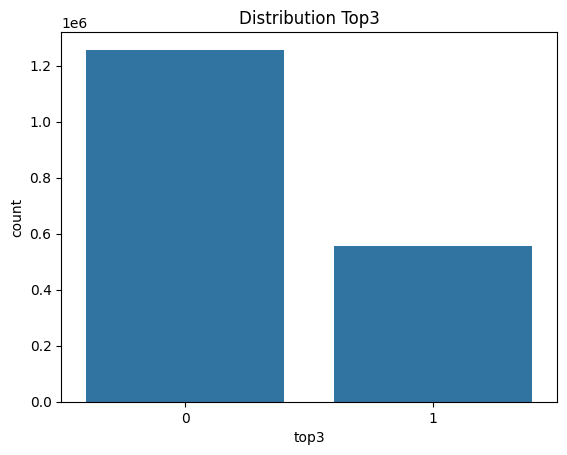

np.float64(0.30606611102187087)

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='top3', data=df)
plt.title("Distribution Top3")
plt.show()

df['top3'].mean()

Le dataset présente un déséquilibre modéré (30% d’observations positives), cohérent avec la structure des courses hippiques. Aucun rééquilibrage n’a été effectué dans un premier temps afin de préserver la distribution réelle du phénomène étudié. Des méthodes de pondération pourront être envisagées lors de la phase de modélisation si nécessaire.

 Histogramme des variables quantitatives 

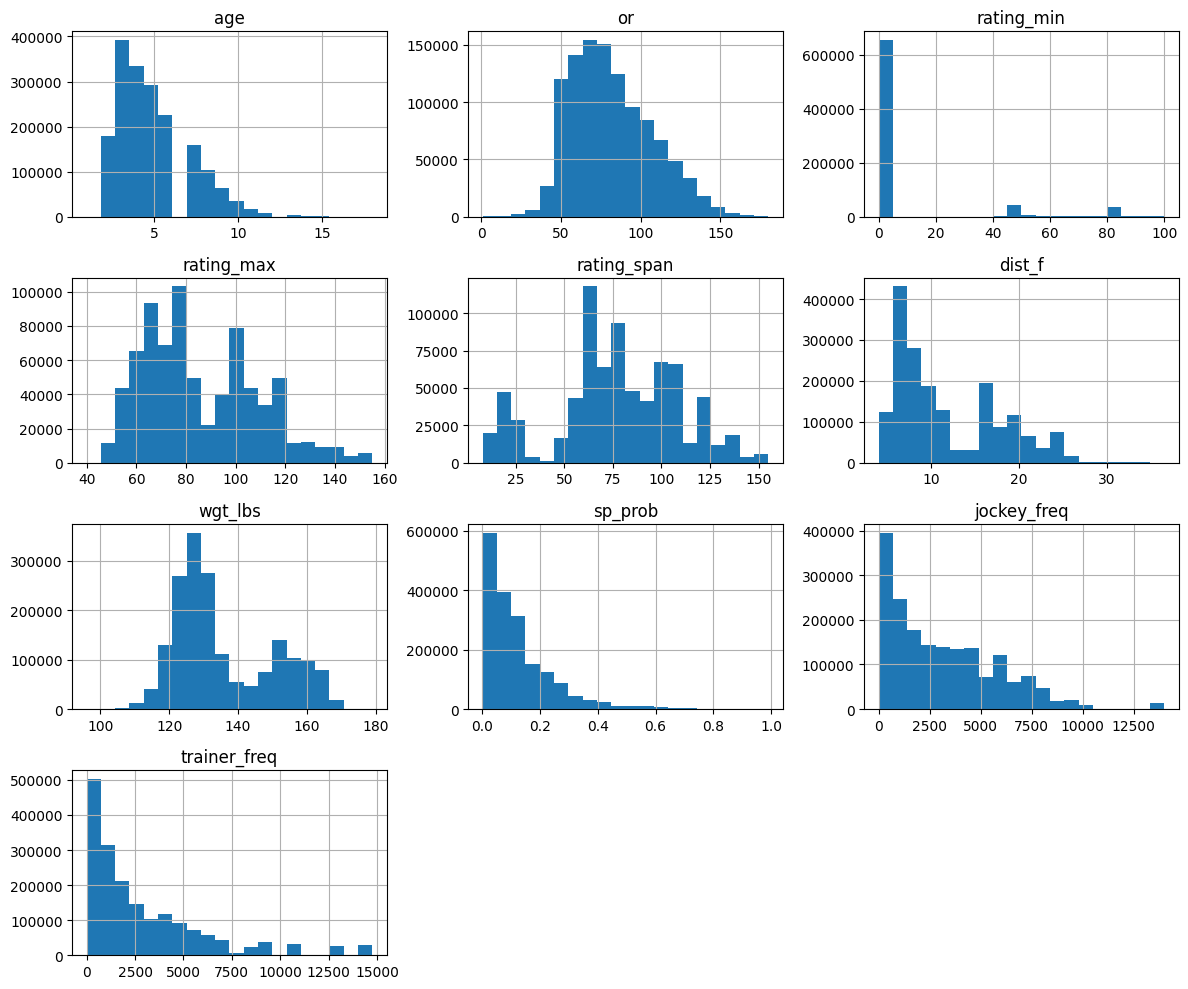

In [83]:
df[var_quant_histo].hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

In [54]:
df[var_quant_histo].skew()

age             0.850350
or              0.536433
rating_min      2.493627
rating_max      0.568092
rating_span    -0.131231
dist_f          0.792596
wgt_lbs         0.657245
sp_prob         2.077197
jockey_freq     0.999010
trainer_freq    1.732404
dtype: float64

L’analyse visuelle des distributions confirme globalement les constats issus des statistiques descriptives. La majorité des variables liées au niveau de performance et à la structure des courses présente une dispersion importante, traduisant l’hétérogénéité du contexte compétitif.

Les histogrammes mettent particulièrement en évidence l’asymétrie marquée de certaines variables, notamment la probabilité implicite des bookmakers ainsi que les fréquences d’activité des jockeys et entraîneurs. Cette structure suggère une concentration de l’information et de l’expérience autour d’un nombre limité d’acteurs ou de favoris.

Par ailleurs, la présence de distributions multimodales pour certaines variables de course confirme l’existence de segments compétitifs distincts (types de distance ou niveaux de compétition), ce qui pourra influencer la capacité prédictive des modèles.

Le skewness permet egalement de se rendre compte que les variables ne sont pas tant asymétriques, seul rating_min et sp_prob présente un skewness supérieur a 2. Toutefois ces résultats ne sont pas impressionant. 

Ces éléments  confortent ainsi l’idée d’un environnement de compétition fortement structuré, caractérisé par des effets de hiérarchie et de spécialisation.

## 4.2 Boxplots avec TARGET

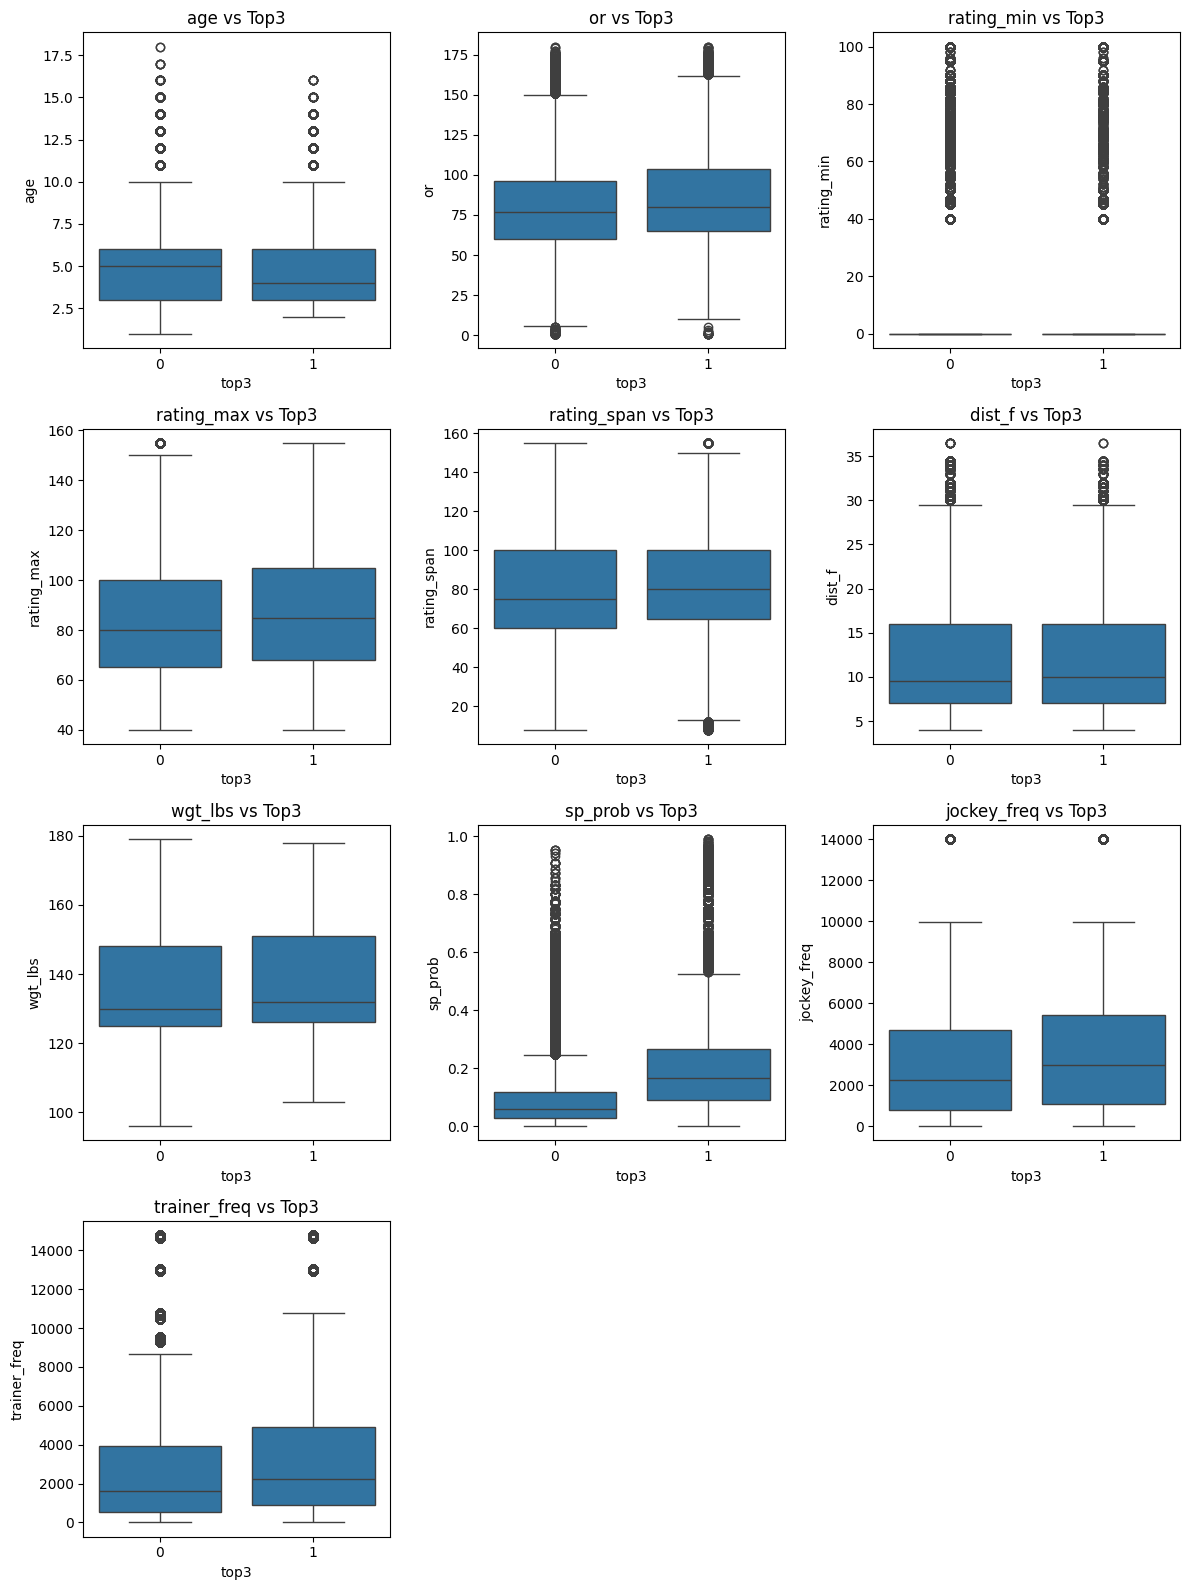

In [55]:
n_cols = 3
n_rows = int(np.ceil(len(var_quant_histo) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))

axes = axes.flatten()

for i, var in enumerate(var_quant_histo):
    sns.boxplot(x='top3', y=var, data=df, ax=axes[i])
    axes[i].set_title(f"{var} vs Top3")

# supprimer les axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

""L’analyse des boxplots met en évidence plusieurs différences notables entre les chevaux terminant dans le top 3 et les autres, suggérant l’existence de déterminants structurels de la performance.

Tout d’abord, le rating officiel apparaît nettement plus élevé en moyenne pour les chevaux classés dans le top 3, confirmant son rôle central comme indicateur de niveau. De manière cohérente, les variables liées à la structure compétitive de la course (rating_max et rating_span) présentent également des niveaux plus élevés pour les chevaux performants, ce qui peut traduire une sélection plus forte dans les courses de haut niveau.

La probabilité implicite des bookmakers constitue la variable la plus discriminante visuellement : les chevaux terminant dans le top 3 présentent des probabilités nettement supérieures. Cela suggère que le marché des paris agrège efficacement l’information disponible sur les chances de performance.

Les variables liées aux acteurs humains montrent également un effet positif : les chevaux montés par des jockeys plus actifs et entraînés par des entraîneurs plus expérimentés ont une probabilité plus élevée d’atteindre le top 3. Cela confirme l’importance des effets d’expérience et de réputation dans les résultats des courses.

En revanche, certaines variables apparaissent moins discriminantes. L’âge montre une différence limitée entre les groupes, suggérant que l’effet de maturité est relativement homogène dans l’échantillon. De même, le poids porté présente une séparation modérée, ce qui peut refléter l’efficacité du mécanisme de handicap dans l’équilibrage des performances.

Enfin, la variable rating_min ne semble pas apporter d’information discriminante, en raison de sa forte concentration en valeurs nulles. Elle pourrait donc avoir une contribution limitée dans les modèles prédictifs.

Dans l’ensemble, ces résultats suggèrent que la performance en course dépend principalement du niveau intrinsèque du cheval, de l’information de marché et des effets liés aux acteurs humains, tandis que certaines caractéristiques structurelles jouent un rôle plus secondaire.""

## 4.3 Analyse des variables binaires 

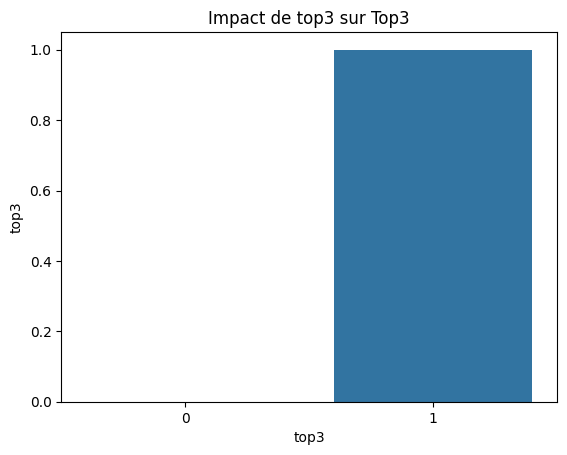

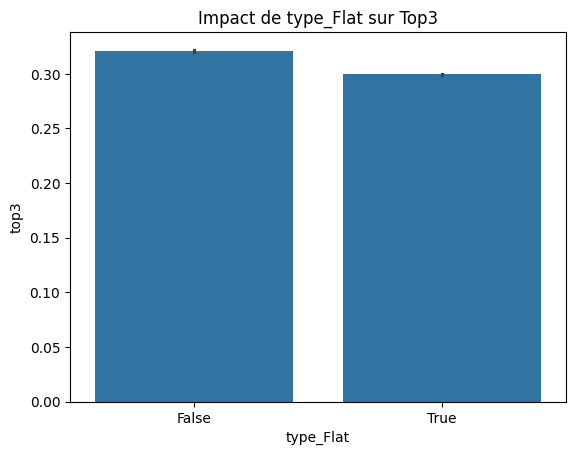

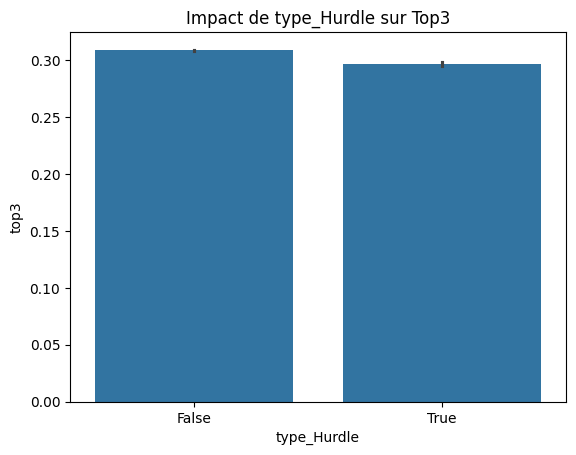

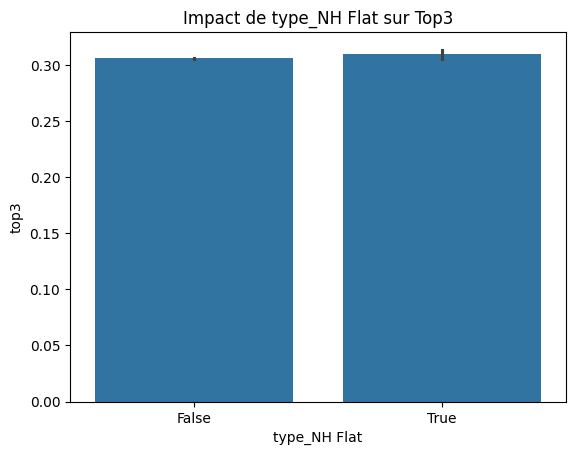

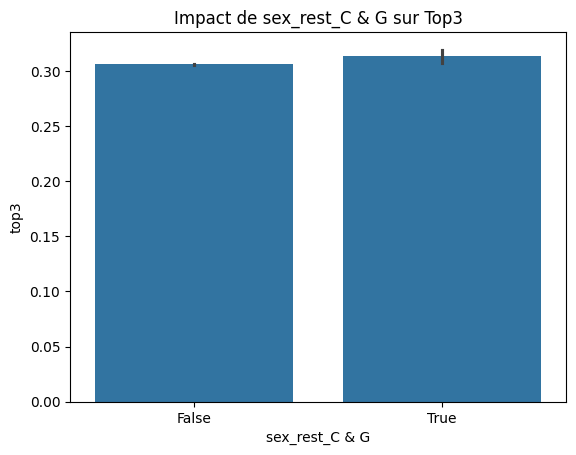

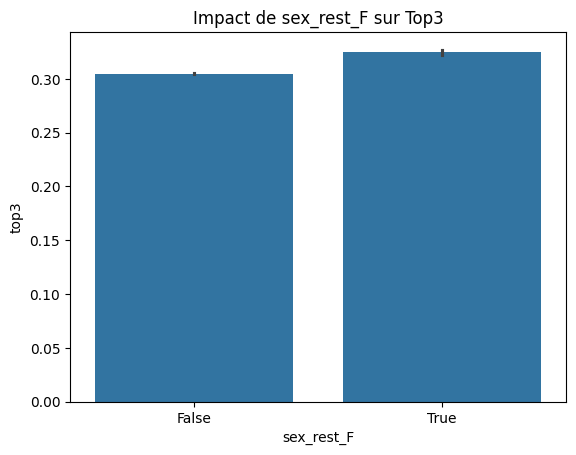

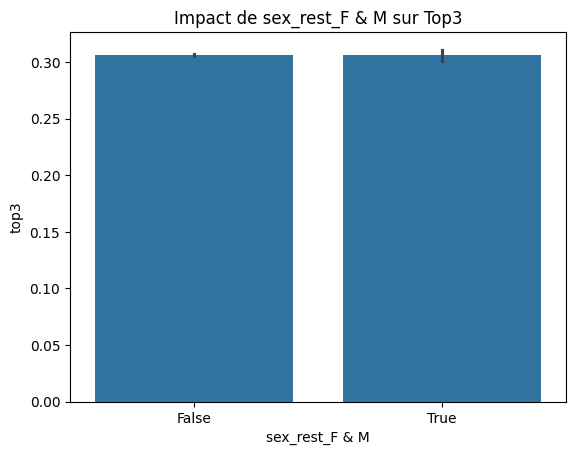

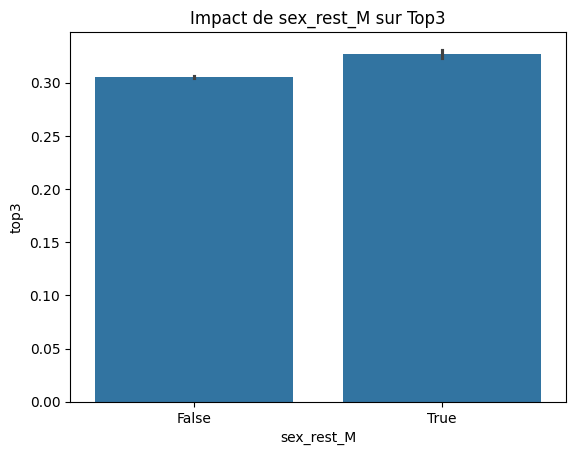

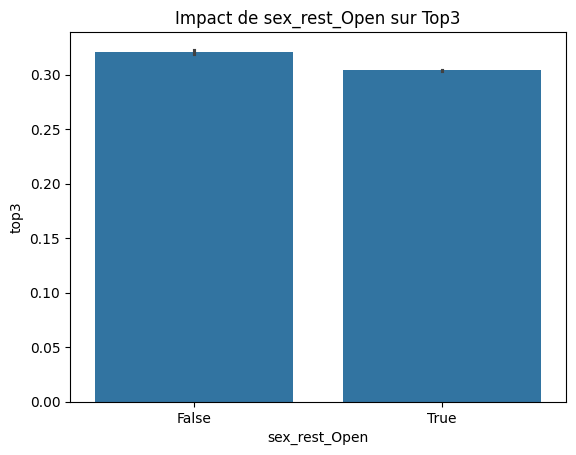

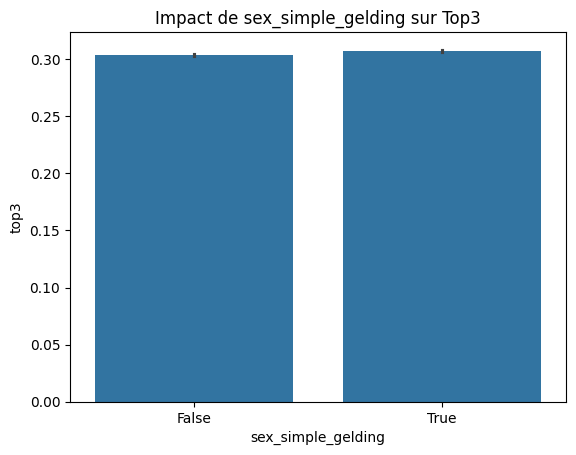

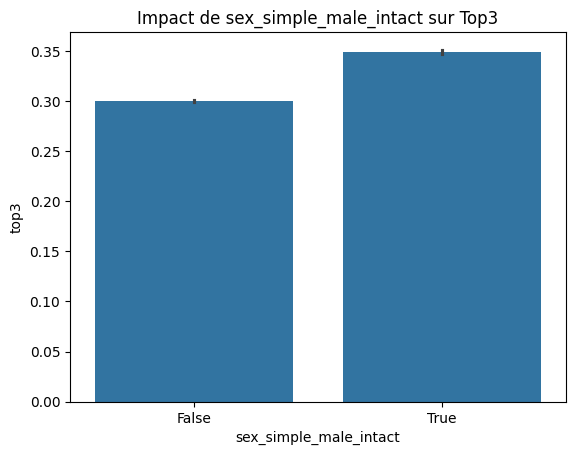

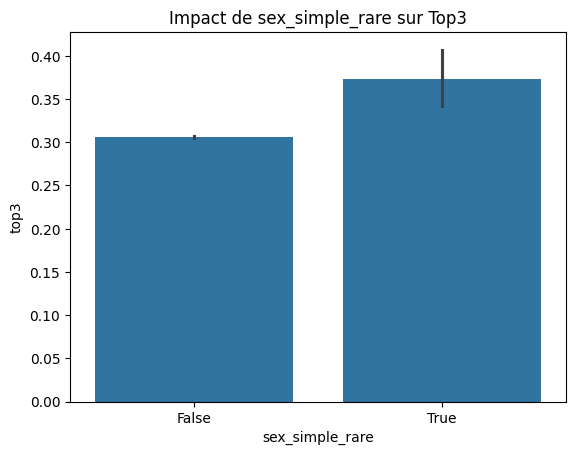

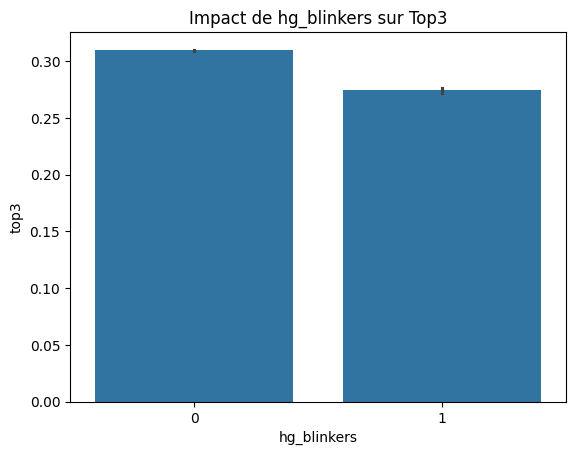

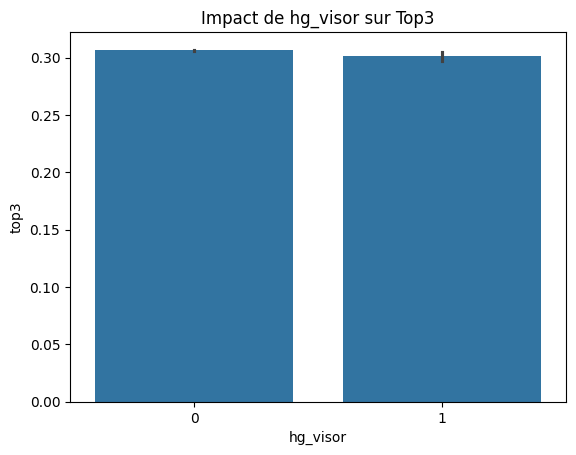

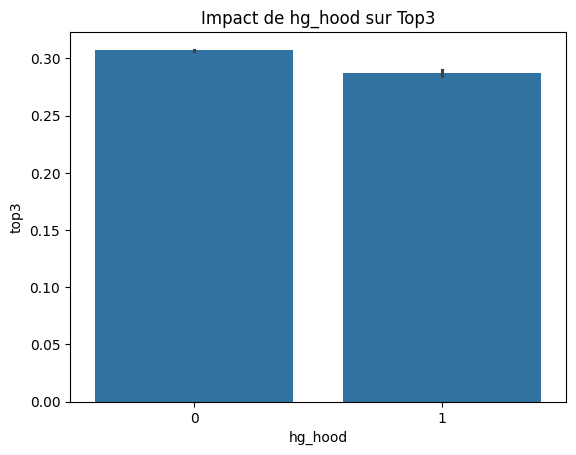

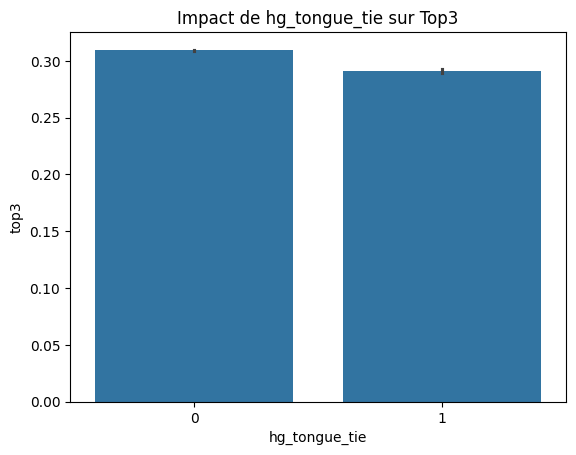

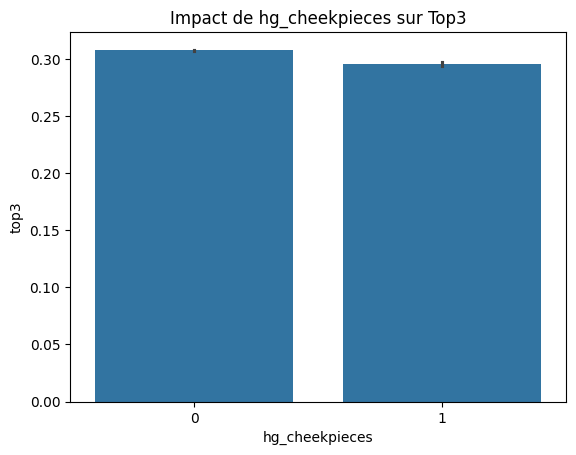

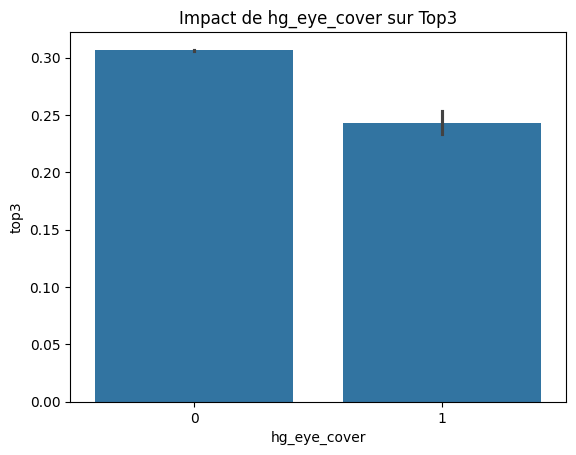

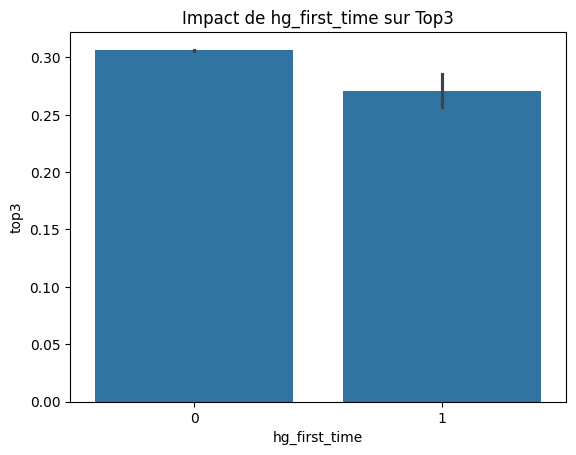

In [56]:
for var in var_bin:
    plt.figure()
    sns.barplot(x=var, y='top3', data=df)
    plt.title(f"Impact de {var} sur Top3")
    plt.show()

L’examen des variables binaires met en évidence un pouvoir discriminant globalement limité vis-à-vis de la probabilité de terminer dans le top 3. Pour la majorité d’entre elles, les proportions d’occurrence sont relativement similaires entre les chevaux performants et les autres, ce qui suggère une capacité prédictive modérée prise isolément.

Certaines variables liées au sexe du cheval présentent toutefois des écarts plus marqués. En particulier, les chevaux mâles non castrés (`sex_simple_male_intact`) ainsi que les catégories plus rares (`sex_simple_rare`) apparaissent proportionnellement plus représentés parmi les chevaux terminant dans le top 3. Cela peut refléter des différences de sélection ou de spécialisation sportive selon les profils biologiques.

À l’inverse, plusieurs variables associées à l’équipement, telles que les œillères (`hg_blinkers`), les protections oculaires (`hg_eye_cover`) ou leur utilisation pour la première fois (`hg_first_time`), sont davantage observées chez les chevaux ne terminant pas dans le top 3. Ce résultat peut s’interpréter comme un effet de correction comportementale : ces équipements sont souvent utilisés pour améliorer la concentration ou la performance de chevaux présentant certaines limites, ce qui pourrait expliquer leur association plus fréquente avec des résultats moins favorables.

Dans l’ensemble, ces variables binaires semblent jouer un rôle secondaire comparativement aux indicateurs de niveau intrinsèque ou d’information de marché. Leur contribution éventuelle à la modélisation pourrait néanmoins apparaître dans des interactions ou des effets non linéaires.

### 4.4 corrélation globale

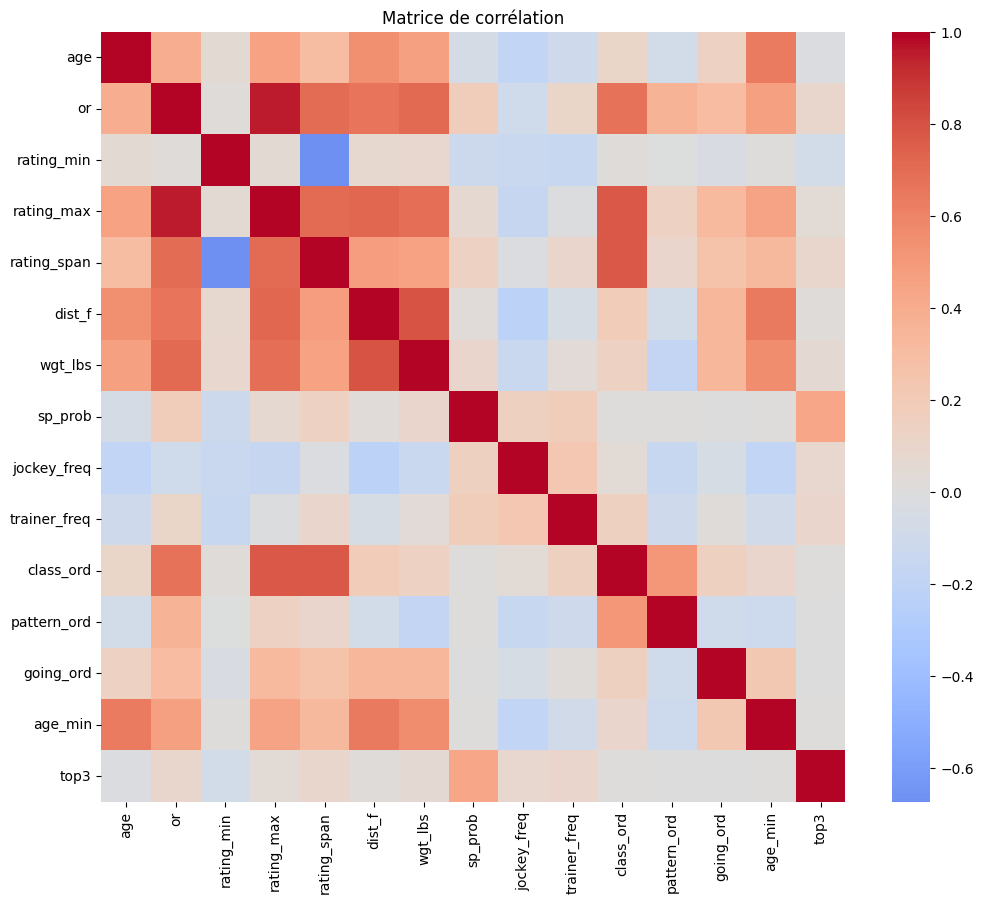

Corrélations positives fortes :
     Variable_1   Variable_2  Correlation
18           or   rating_max     0.953641
81       dist_f      wgt_lbs     0.790364
55   rating_max    class_ord     0.776155
70  rating_span    class_ord     0.773522
50   rating_max       dist_f     0.722992
21           or      wgt_lbs     0.718636
49   rating_max  rating_span     0.705439

Corrélations négatives fortes :
Aucune corrélation négative < -0.7


In [57]:
corr = df[var_corr + ['top3']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation")
plt.show()


mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

pairs_corr = corr.where(mask).stack().reset_index()
pairs_corr.columns = ['Variable_1', 'Variable_2', 'Correlation']

strong_corr_pos = pairs_corr[pairs_corr['Correlation'] > 0.7].sort_values(
    by='Correlation', ascending=False
)

strong_corr_neg = pairs_corr[pairs_corr['Correlation'] < -0.7].sort_values(
    by='Correlation', ascending=True
)

print("Corrélations positives fortes :")
print(strong_corr_pos if not strong_corr_pos.empty else "Aucune corrélation positive > 0.7")

print("\nCorrélations négatives fortes :")
print(strong_corr_neg if not strong_corr_neg.empty else "Aucune corrélation négative < -0.7")

L’analyse de la matrice de corrélation met en évidence l’existence de certaines corrélations positives élevées entre variables explicatives. En particulier, la corrélation très forte observée entre le rating officiel du cheval (`or`) et le rating maximal de la course (`rating_max`) ( 0,95) suggère une proximité informationnelle importante entre ces deux indicateurs de niveau. De même, une corrélation notable est observée entre la distance de la course (`dist_f`) et le poids porté (`wgt_lbs`) (0,79), ce qui peut refléter des mécanismes structurels propres à l’organisation des courses.

Au total, septs couples de variables présentent des corrélations élevées, ce qui soulève la question d’un risque potentiel de multicolinéarité dans les modèles économétriques ou prédictifs. Toutefois, la présence de corrélations fortes ne justifie pas nécessairement une suppression immédiate des variables concernées. Une analyse complémentaire, notamment via des indicateurs tels que le VIF ou l’importance des variables dans les modèles, sera nécessaire afin d’évaluer leur contribution réelle à l’explication de la performance.

### 4.5  Les corrélations avec la variable cible (Top3)

In [58]:
# Corrélation avec la cible
corr_target = corr['top3'].drop('top3')

# Top 10 positives
top10_pos = corr_target.sort_values(ascending=False).head(10)

# Top 10 négatives
top10_neg = corr_target.sort_values().head(10)

print("Top 10 corrélations positives avec top3 :")
print(top10_pos)

print("\nTop 10 corrélations négatives avec top3 :")
print(top10_neg)



Top 10 corrélations positives avec top3 :
sp_prob         0.436690
trainer_freq    0.094094
or              0.089770
rating_span     0.088583
jockey_freq     0.085165
wgt_lbs         0.056182
rating_max      0.042566
dist_f          0.021858
class_ord       0.008105
age_min         0.007990
Name: top3, dtype: float64

Top 10 corrélations négatives avec top3 :
rating_min    -0.080389
age           -0.019350
pattern_ord    0.001287
going_ord      0.002494
age_min        0.007990
class_ord      0.008105
dist_f         0.021858
rating_max     0.042566
wgt_lbs        0.056182
jockey_freq    0.085165
Name: top3, dtype: float64


Afin de prolonger l’analyse des relations entre variables, il est pertinent d’examiner les corrélations entre les variables explicatives et la variable cible (Top 3). Dans l’ensemble, les coefficients de corrélation observés sont faibles et proches de zéro, suggérant l’absence de relation linéaire forte prise isolément. Cela indique que la performance en course dépend probablement d’une combinaison de facteurs plutôt que d’un déterminant unique.

Une exception notable apparaît toutefois avec la variable `sp_prob`, qui présente une corrélation plus marquée avec la variable cible. Ce résultat est cohérent avec le fait que la probabilité implicite issue des bookmakers agrège une large quantité d’information sur les chances de performance des chevaux. Cette variable constitue ainsi un indicateur synthétique central, susceptible de jouer un rôle important dans les modèles prédictifs.

Ces résultats soulignent la nécessité d’utiliser des approches multivariées et potentiellement non linéaires pour capturer les mécanismes déterminant la performance.

## 4.6  Pairplot variables clés

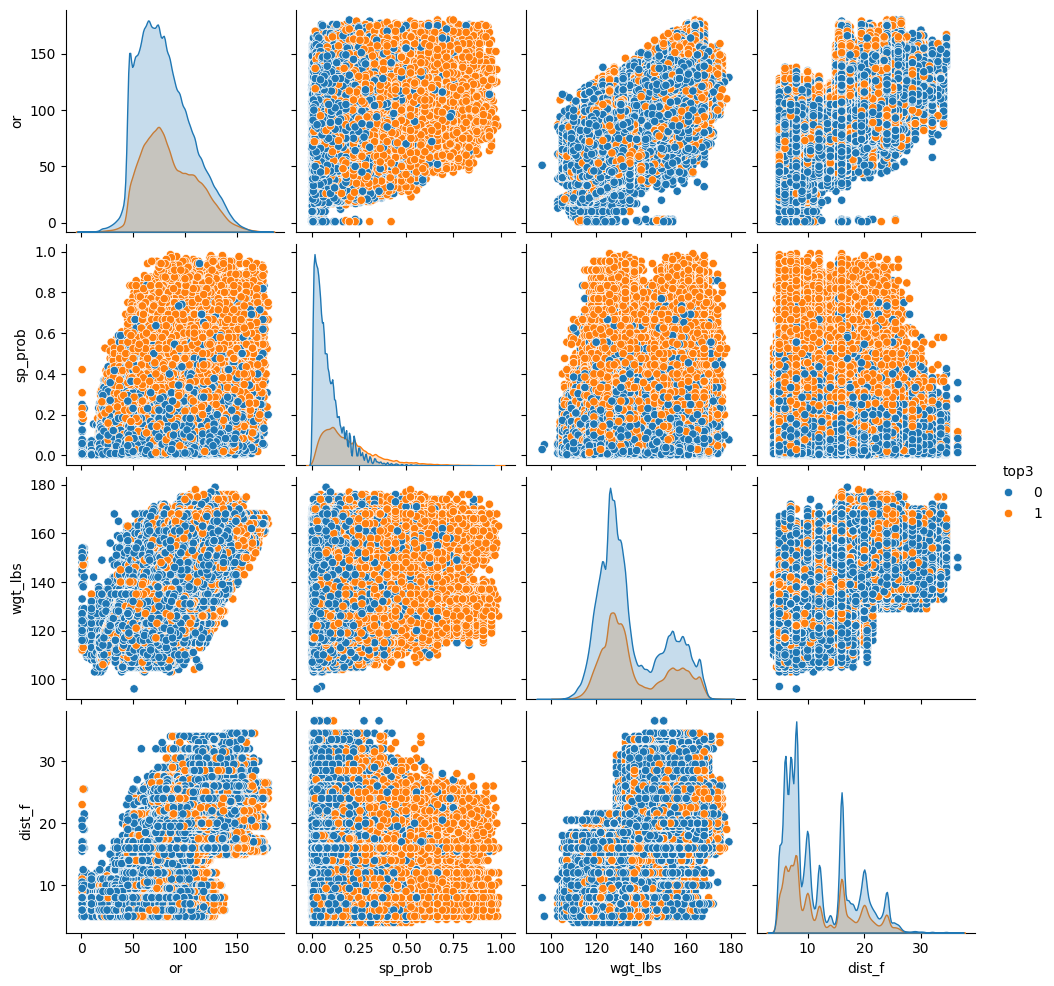

In [59]:
sns.pairplot(df[['or','sp_prob','wgt_lbs','dist_f','top3']], hue='top3')
plt.show()

L’analyse conjointe des principales variables quantitatives met en évidence plusieurs structures importantes dans les données. Tout d’abord, la probabilité implicite issue des bookmakers (`sp_prob`) apparaît comme le facteur le plus discriminant visuellement : les observations associées à une probabilité plus élevée sont nettement plus fréquemment liées à une performance dans le top 3. Cela confirme le rôle central de l’information de marché dans l’anticipation des résultats.

Par ailleurs, une relation positive est observée entre le rating officiel (`or`) et le poids porté (`wgt_lbs`), reflétant le mécanisme des courses handicap où les chevaux les plus performants se voient attribuer un poids plus important. Cette structure traduit une logique institutionnelle du système de compétition.

La distance de course (`dist_f`) ne semble pas présenter de séparation nette entre les chevaux performants et les autres, suggérant que son effet est probablement conditionnel à d’autres caractéristiques, telles que le niveau du cheval ou le type de course.

Globalement, la superposition importante des observations entre les groupes confirme que la performance ne peut être expliquée par une variable unique, mais résulte plutôt d’interactions complexes entre niveau intrinsèque, structure de la course et information de marché.

## 5)  Analyse temporelle 

C:\Users\33783\AppData\Local\Temp\ipykernel_27664\2605735713.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df.groupby('month')['top3'].mean().plot()


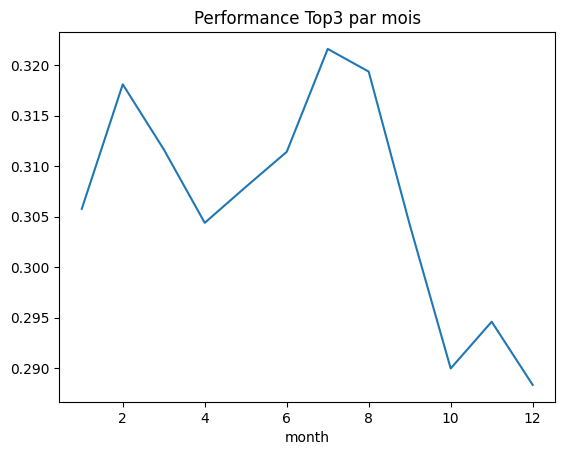

In [60]:
df.groupby('month')['top3'].mean().plot()
plt.title("Performance Top3 par mois")
plt.show()

C:\Users\33783\AppData\Local\Temp\ipykernel_27664\2143621332.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df.groupby('year')['top3'].mean().plot()


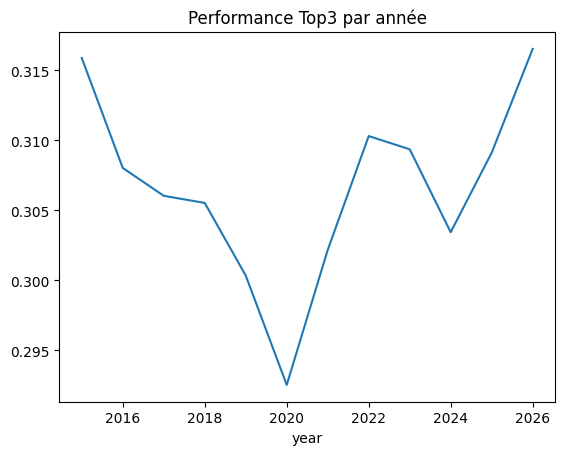

In [97]:
df.groupby('year')['top3'].mean().plot()
plt.title("Performance Top3 par année")
plt.show()

L’analyse temporelle met en évidence une répartition inégale des courses au cours de l’année. Les mois de printemps et d’été, notamment mai, juillet et août, concentrent une part plus importante des observations, ce qui reflète la saisonnalité naturelle des activités hippiques liée aux conditions météorologiques. À l’inverse, l’activité est plus limitée durant les mois hivernaux, en particulier en décembre.

Sur le plan annuel, le nombre de courses varie également selon les années. Une baisse marquée est observée en 2020, probablement liée aux perturbations engendrées par la pandémie de COVID-19, suivie d’un rebond progressif. La tendance récente semble indiquer une reprise et une légère hausse du volume de courses.

## 6)  Transformation des variables a la suite de l'analyse descriptive

In [98]:
# 1) on regle le proble de rating_min en creant une variable binaire indiquant si rating_min est supérieur à 0 ou pas ( 1 si > 0, 0 sinon )
df['has_rating_min'] = (df['rating_min'] > 0).astype(int)

# 2) on met en log les variables tres asymétriques : 
df['log_jockey_freq'] = np.log1p(df['jockey_freq'])
df['log_trainer_freq'] = np.log1p(df['trainer_freq'])
df['log_sp_prob'] = np.log1p(df['sp_prob'])

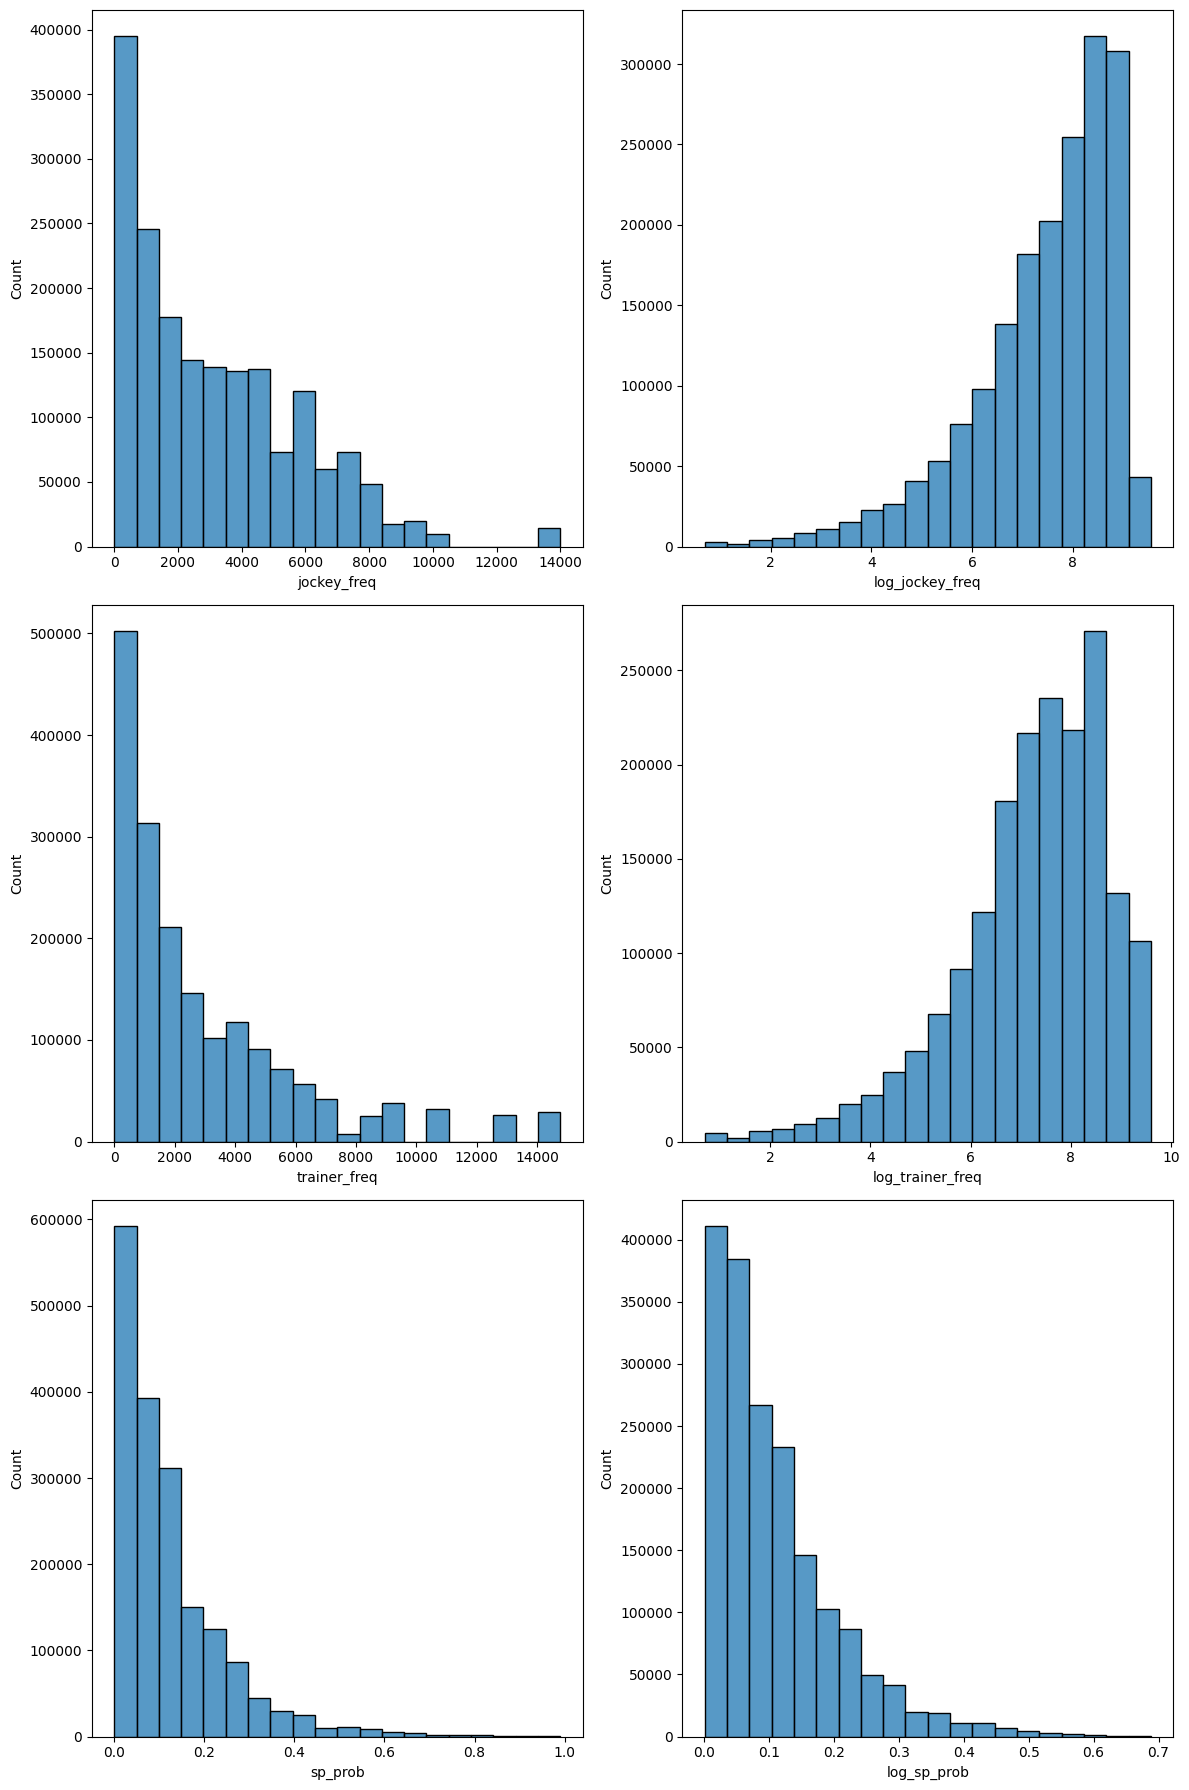

In [63]:
# voir l'effet de ces transformations sur la distribution des variables
fig, axes = plt.subplots(3, 2, figsize=(12, 18))
sns.histplot(df['jockey_freq'], ax=axes[0, 0], bins=20)
sns.histplot(df['log_jockey_freq'], ax=axes[0, 1], bins=20)
sns.histplot(df['trainer_freq'], ax=axes[1, 0], bins=
20)
sns.histplot(df['log_trainer_freq'], ax=axes[1, 1], bins=20)
sns.histplot(df['sp_prob'], ax=axes[2, 0], bins=20)
sns.histplot(df['log_sp_prob'], ax=axes[2, 1], bins=20)
plt.tight_layout()
plt.show()


In [ ]:
# on reduit le dataset en echantillonnant 20% des données pour chaque combinaison de top3 et d'année  paceque bcp trop de données 
df = pd.concat(
    [g.sample(frac=0.2, random_state=42) for _, g in df.groupby(['top3', 'year'])],
    ignore_index=True
)


 Un sous-échantillonnage a été réalisé de manière stratifiée selon l’année et la variable cible, en conservant une proportion fixe des observations dans chaque groupe. Cette approche permet de réduire la taille du dataset tout en préservant sa structure temporelle et la distribution de la variable cible.

## 7) Fixage des variables a garder pour l'analyse 

On fixe la base finale des variables a garder pour la suite 

In [65]:
features = [

    # cheval
    'age',
    'or',
    'wgt_lbs',
    'draw',

    # course
    'dist_f',
    'class_ord',
    'pattern_ord',
    'going_ord',
    'rating_max',
    'rating_span',
    'age_min',
    'has_rating_min',

    # type course
    'type_Flat',
    'type_Hurdle',
    'type_NH Flat',

    # sexe (version simplifiée)
    'sex_simple_gelding',
    'sex_simple_male_intact',
    'sex_simple_rare',

    # équipement
    'hg_blinkers',
    'hg_visor',
    'hg_hood',
    'hg_tongue_tie',
    'hg_cheekpieces',
    'hg_eye_cover',
    'hg_first_time',

    # humain / marché
    'log_jockey_freq',
    'log_trainer_freq',
    'log_sp_prob',

    # temps
    'year',
    'month',

    # data quality
    'or_missing'
]

## 8) Faire le split train / test temporel

In [101]:
train = df[df['year'] <= 2022].copy()
test = df[df['year'] > 2022].copy()

In [102]:
X_train = train[features]
X_test = test[features]
y_train = train['top3']
y_test = test['top3']

Création d'une fonction d'évaluation des performances : 

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name="Model"):
    model.fit(X_tr, y_tr)
    
    y_pred = model.predict(X_te)
    
    # Pour ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_te)
    else:
        y_proba = None
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1": f1_score(y_te, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_te, y_proba) if y_proba is not None else None
    }
    
    print(f"\n=== {model_name} ===")
    print("Confusion matrix :")
    print(confusion_matrix(y_te, y_pred))
    print("\nClassification report :")
    print(classification_report(y_te, y_pred, zero_division=0))
    
    return model, results

## 8.1 )Préparation  d'une version standardisée pour modèle linéaire et SVM


Il y a des NA dans certaines variables c'est poruquoi il a été decidé de remplacer ces valeurs par la médiane. 

In [ ]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

X_train_imputed = num_imputer.fit_transform(X_train)
X_test_imputed = num_imputer.transform(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [ ]:
df.isna().mean().sort_values(ascending=False).head(15)

rating_min        0.586278
rating_span       0.586278
rating_max        0.586278
class_ord         0.416096
or                0.403126
draw              0.319672
sp_prob           0.004904
log_sp_prob       0.004904
going_ord         0.002627
age_min           0.000069
sex_rest_F        0.000000
sex_rest_F & M    0.000000
sex_rest_M        0.000000
sex_rest_Open     0.000000
dist_f            0.000000
dtype: float64

## 9) Modélisation 
9.1) Modèle 1 : régression logistique

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced', # on utilise balanced pour compenser le déséquilibre de la classe cible
    random_state=42
)

log_reg_model, log_reg_results = evaluate_model(
    log_reg,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    model_name="Logistic Regression"
)


=== Logistic Regression ===
Confusion matrix :
[[55471 16348]
 [11972 19968]]

Classification report :
              precision    recall  f1-score   support

           0       0.82      0.77      0.80     71819
           1       0.55      0.63      0.59     31940

    accuracy                           0.73    103759
   macro avg       0.69      0.70      0.69    103759
weighted avg       0.74      0.73      0.73    103759



In [ ]:
roc_auc_score(y_test, log_reg_model.predict_proba(X_test_scaled)[:,1])

0.7780048136036826

**Résultats**

Le modèle de régression logistique présente des performances globalement satisfaisantes avec une accuracy d’environ 73%. Toutefois, cette métrique doit être interprétée avec prudence en raison du déséquilibre modéré de la variable cible.

L’analyse plus fine des métriques montre que le modèle parvient relativement bien à identifier les chevaux ne terminant pas dans le top 3 (classe 0), avec une précision de 0,82 et un recall de 0,77. En revanche, les performances sont plus modestes pour la détection des chevaux terminant dans le top 3 (classe 1), avec une précision de 0,55 et un recall de 0,62.

Cela signifie que le modèle est capable d’identifier une partie significative des chevaux performants, mais au prix d’un nombre non négligeable de faux positifs. Ce comportement est cohérent avec la nature du problème : la performance en course dépend de nombreux facteurs et reste difficile à prédire de manière parfaitement déterministe.

Le F1-score de la classe positive (≈ 0,58) confirme ce compromis entre précision et rappel. Par ailleurs, les scores macro et pondérés suggèrent un équilibre global correct entre les deux classes, sans biais excessif vers la classe majoritaire.

9.2) Modèle 2 : SVM Linéaire 

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_base = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

# Calibré pour obtenir des probabilités
svm = CalibratedClassifierCV(svm_base, cv=3)

svm_model, svm_results = evaluate_model(
    svm,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    model_name="Linear SVM"
)


=== Linear SVM ===
Confusion matrix :
[[66098  5721]
 [20329 11611]]

Classification report :
              precision    recall  f1-score   support

           0       0.76      0.92      0.84     71819
           1       0.67      0.36      0.47     31940

    accuracy                           0.75    103759
   macro avg       0.72      0.64      0.65    103759
weighted avg       0.74      0.75      0.72    103759




**Résultats** 

Le modèle SVM linéaire présente une amélioration légère de l’accuracy globale (75%) par rapport à la régression logistique. Toutefois, cette amélioration masque des différences importantes dans la capacité de prédiction selon les classes.

Le modèle est particulièrement performant pour identifier les chevaux ne terminant pas dans le top 3 (classe 0), avec un recall élevé de 0,92. En revanche, sa capacité à détecter les chevaux performants (classe 1) est nettement plus limitée, avec un recall de seulement 0,36.

Cela signifie que le modèle adopte une stratégie différente, en classant plus fréquemment les observations dans la classe majoritaire, ce qui réduit le nombre de faux positifs mais augmente fortement les faux négatifs. Il manque donc  une part importante des chevaux terminant effectivement dans le top 3.

Ce comportement se traduit également par un F1-score plus faible pour la classe positive ( 0,47), indiquant une dégradation de la capacité globale à identifier les performances par rapport à la régression logistique.

Ainsi, bien que le SVM améliore légèrement la précision globale, il apparaît moins adapté à l’objectif principal de détection des chevaux performants. 

9.3) Modèle 3 : Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    n_jobs=-1,
    class_weight='balanced_subsample',
    random_state=42
)

rf_model, rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name="Random Forest"
)


=== Random Forest ===
Confusion matrix :
[[49093 22726]
 [ 8802 23138]]

Classification report :
              precision    recall  f1-score   support

           0       0.85      0.68      0.76     71819
           1       0.50      0.72      0.59     31940

    accuracy                           0.70    103759
   macro avg       0.68      0.70      0.68    103759
weighted avg       0.74      0.70      0.71    103759



**Résultats** 

Le modèle Random Forest présente une accuracy légèrement inférieure (70%) à celle des modèles précédents. Toutefois, cette baisse globale s’accompagne d’une amélioration significative de la capacité à détecter les chevaux terminant dans le top 3.

En effet, le recall de la classe positive atteint environ 0,73, ce qui constitue la meilleure performance parmi les modèles testés. Cela signifie que le modèle est capable d’identifier une proportion importante des chevaux performants. En revanche, cette amélioration se fait au détriment de la précision (0,51), traduisant un nombre plus élevé de faux positifs.

Ce comportement montre une stratégie plus risqué du modèle, qui privilégie la détection des performances au risque de surestimer certaines observations. Ce compromis est cohérent avec la nature non linéaire du modèle, capable de capturer des interactions complexes entre variables.

Ainsi,  le random forest apparaît  plus adapté pour identifier les chevaux susceptibles de terminer dans le top 3, bien que sa précision globale soit plus faible.

9.4) Modèle 4  : XGBOOST 

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(),  # gestion déséquilibre
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model, xgb_results = evaluate_model(
    xgb,
    X_train,   # pas besoin de scaling
    X_test,
    y_train,
    y_test,
    model_name="XGBoost"
)

c:\Users\33783\Desktop\M2\SVM\cours_iae\04_INTERPRETABLE_ML\.venv04\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:45:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
Confusion matrix :
[[49136 22683]
 [ 8828 23112]]

Classification report :
              precision    recall  f1-score   support

           0       0.85      0.68      0.76     71819
           1       0.50      0.72      0.59     31940

    accuracy                           0.70    103759
   macro avg       0.68      0.70      0.68    103759
weighted avg       0.74      0.70      0.71    103759



9.5 Modele 5 : BaggingClassifier

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    ),
    n_estimators=100,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bagging_model, bagging_results = evaluate_model(
    bagging,
    X_train,   # pas besoin de scaling
    X_test,
    y_train,
    y_test,
    model_name="Bagging Classifier"
)


=== Bagging Classifier ===
Confusion matrix :
[[64576  7243]
 [18714 13226]]

Classification report :
              precision    recall  f1-score   support

           0       0.78      0.90      0.83     71819
           1       0.65      0.41      0.50     31940

    accuracy                           0.75    103759
   macro avg       0.71      0.66      0.67    103759
weighted avg       0.74      0.75      0.73    103759



9.6 modele 6 : KNN 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=15,   # nombre de voisins
    weights='distance',  # pondération par distance (meilleur en pratique)
    n_jobs=-1
)

knn_model, knn_results = evaluate_model(
    knn,
    X_train_scaled,   #  très important de scaled 
    X_test_scaled,
    y_train,
    y_test,
    model_name="KNN"
)


=== KNN ===
Confusion matrix :
[[65795  6024]
 [21698 10242]]

Classification report :
              precision    recall  f1-score   support

           0       0.75      0.92      0.83     71819
           1       0.63      0.32      0.42     31940

    accuracy                           0.73    103759
   macro avg       0.69      0.62      0.63    103759
weighted avg       0.71      0.73      0.70    103759



9.7 model 7 : MLP  

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 couches cachées
    activation='relu',
    solver='adam',
    alpha=0.0001,                  # régularisation
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    random_state=42
)

mlp_model, mlp_results = evaluate_model(
    mlp,
    X_train_scaled,   #  très important
    X_test_scaled,
    y_train,
    y_test,
    model_name="MLP Classifier"
)


=== MLP Classifier ===
Confusion matrix :
[[63506  8313]
 [17760 14180]]

Classification report :
              precision    recall  f1-score   support

           0       0.78      0.88      0.83     71819
           1       0.63      0.44      0.52     31940

    accuracy                           0.75    103759
   macro avg       0.71      0.66      0.68    103759
weighted avg       0.73      0.75      0.73    103759



## 10) Comparaison des différents modèles 

Tableau comparatif des performances

In [ ]:
results_df = pd.DataFrame([
    log_reg_results,
    svm_results,
    rf_results, 
    mlp_results,
    xgb_results,
    bagging_results,
    knn_results
    
])

results_df.sort_values(by="ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
5,Bagging Classifier,0.749834,0.646148,0.414089,0.504722,0.780714
4,XGBoost,0.696306,0.504684,0.723607,0.594636,0.779235
0,Logistic Regression,0.727060,0.549840,0.625172,0.585091,0.778005
2,Random Forest,0.696142,0.504492,0.724421,0.594777,0.777483
1,Linear SVM,0.748937,0.669917,0.363525,0.471302,0.777442
3,MLP Classifier,0.748716,0.630418,0.443957,0.521007,0.777092
6,KNN,0.732823,0.629657,0.320664,0.424926,0.711079


Le Random Forest apparaît comme le modèle le plus pertinent pour notre objectif, en raison de sa capacité à identifier efficacement les chevaux terminant dans le top 3, comme en témoigne son recall élevé et son F1-score supérieur aux autres modèles. Bien que d’autres modèles présentent une meilleure accuracy globale, ils se révèlent moins performants pour détecter les performances, ce qui constitue pourtant l’objectif principal de l’analyse.

## 11) Tuning des meilleures modeles 
1) Tuning du Random Forest 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12, 15],
    'min_samples_leaf': [10, 20, 50],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train, y_train)

best_rf = rf_random.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
best_rf_model, best_rf_results = evaluate_model(
    best_rf,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name="Random Forest Tuned"
)


=== Random Forest Tuned ===
Confusion matrix :
[[48429 23390]
 [ 8518 23422]]

Classification report :
              precision    recall  f1-score   support

           0       0.85      0.67      0.75     71819
           1       0.50      0.73      0.59     31940

    accuracy                           0.69    103759
   macro avg       0.68      0.70      0.67    103759
weighted avg       0.74      0.69      0.70    103759



**Effet du tuning des hyperparamètres**

L’ajustement des hyperparamètres du modèle Random Forest n’a pas conduit à une amélioration significative des performances. Les résultats obtenus après optimisation sont très proches de ceux du modèle initial, avec un léger gain en recall pour la classe positive, mais une diminution marginale de l’accuracy globale.

Cela suggère que le modèle de base était déjà bien paramétré et que les performances sont davantage limitées par la structure des données que par le choix des hyperparamètres. Ce résultat met en évidence qu’un tuning plus poussé n’aurait probablement pas permis d’obtenir des gains substantiels.

2) Tuning du modele XGBOOST 

In [ ]:
# tuning du modele XGboost

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

print("Best params:", xgb_random.best_params_)
print("Best CV score:", xgb_random.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV score: 0.573786541343307


In [ ]:
best_xgb = xgb_random.best_estimator_

best_xgb_model, best_xgb_results = evaluate_model(
    best_xgb,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name="XGBoost Tuned"
)


=== XGBoost Tuned ===
Confusion matrix :
[[48836 22983]
 [ 8633 23307]]

Classification report :
              precision    recall  f1-score   support

           0       0.85      0.68      0.76     71819
           1       0.50      0.73      0.60     31940

    accuracy                           0.70    103759
   macro avg       0.68      0.70      0.68    103759
weighted avg       0.74      0.70      0.71    103759



**Effet du tuning sur XGBoost**

le tuning des hyperparamètres du modèle XGBoost n’a conduit qu’à une amélioration marginale des performances. Le recall de la classe positive augmente légèrement, tandis que le F1-score progresse très faiblement.

Ces résultats indiquent que le modèle de base était déjà bon en termes de paramétrisation. Comme observé pour le Random Forest, les performances semblent davantage contraintes par la structure et la complexité des données que par le choix des hyperparamètres.

Ainsi, un tuning plus approfondi n’aurait probablement pas permis d’obtenir des gains significatifs, ce qui justifie l’utilisation d’un modèle relativement simple dans la suite de l’analyse.

**Les résultats obtenus avec les modèles Random Forest et XGBoost sont très proches, ce qui suggère que les deux approches capturent efficacement les relations non linéaires présentes dans les données. XGBoost présente une légère amélioration des performances, mais celle-ci reste marginale. Dans la suite de l’analyse, le Random Forest sera privilégié en raison de sa simplicité et de sa meilleure interprétabilité.**

# 12) Interprétabilité du meilleure modele

## 12.1 Importance des variables
- feature importance (RF)
- permutation importance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_importance = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_importance.head(15)

,Variable,Importance
27,log_sp_prob,0.756531
26,log_trainer_freq,0.043523
3,draw,0.031763
25,log_jockey_freq,0.028772
1,or,0.024654
2,wgt_lbs,0.017456
5,class_ord,0.011889
9,rating_span,0.011372
4,dist_f,0.010712
0,age,0.008800


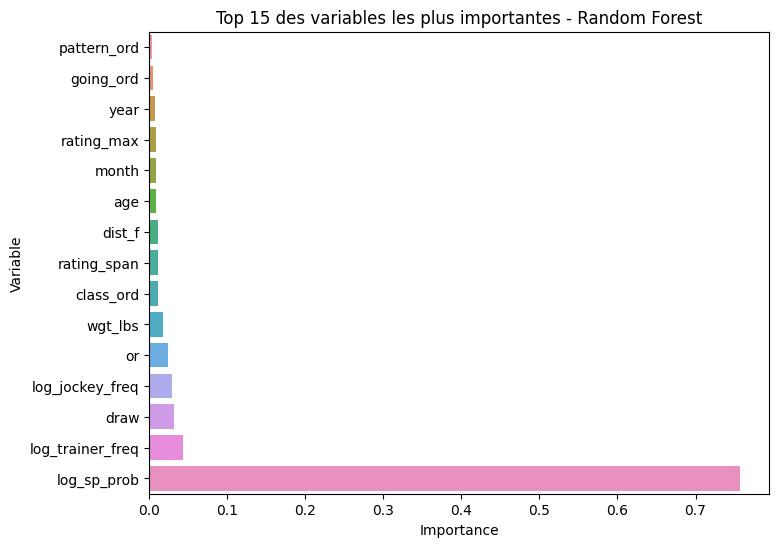

In [ ]:
top_rf = rf_importance.head(15).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_rf, x='Importance', y='Variable')
plt.title("Top 15 des variables les plus importantes - Random Forest")
plt.show()

L’analyse de l’importance des variables met en évidence une forte concentration de l’information sur un nombre restreint de variables. En particulier, la variable `log_sp_prob` domine très largement, avec une importance très supérieure aux autres variables.

Ce résultat indique que la probabilité implicite issue des bookmakers constitue de loin le principal déterminant de la performance, ce qui est cohérent avec l’idée que le marché agrège efficacement l’ensemble de l’information disponible.

Derrière cette variable dominante, plusieurs facteurs apparaissent comme secondaires mais néanmoins pertinents. Les variables liées à l’expérience humaine (`log_trainer_freq`, `log_jockey_freq`) ainsi que certaines caractéristiques structurelles comme la position de départ (`draw`) et le niveau du cheval (`or`) contribuent également à la prédiction.

En revanche, les autres variables présentent des importances relativement faibles, suggérant qu’elles jouent un rôle plus indirect dans la performance. Cela confirme que le modèle repose principalement sur une combinaison d’information de marché et de quelques caractéristiques clés du cheval et de la course.

Il convient toutefois de noter que cette mesure d’importance peut être biaisée en faveur de certaines variables continues ou dominantes. Cette analyse sera donc complétée par une permutation importance afin de confirmer ces résultats.

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='f1',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Variable': X_test.columns,
    'Importance_mean': perm_importance.importances_mean,
    'Importance_std': perm_importance.importances_std
}).sort_values(by='Importance_mean', ascending=False)

perm_df.head(15)

,Variable,Importance_mean,Importance_std
27,log_sp_prob,0.224581,0.001530
3,draw,0.001615,0.000124
12,type_Flat,0.000266,0.000082
2,wgt_lbs,0.000176,0.000126
22,hg_cheekpieces,0.000138,0.000096
4,dist_f,0.000102,0.000124
10,age_min,0.000059,0.000065
19,hg_visor,0.000053,0.000013
30,or_missing,0.000041,0.000145
5,class_ord,0.000028,0.000249


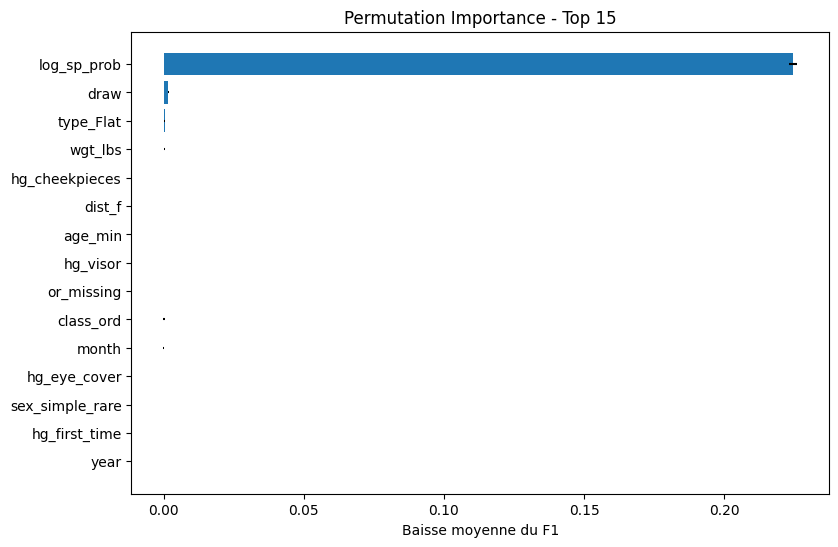

In [ ]:
top_perm = perm_df.head(15).sort_values(by='Importance_mean', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(
    top_perm['Variable'],
    top_perm['Importance_mean'],
    xerr=top_perm['Importance_std']
)
plt.title("Permutation Importance - Top 15")
plt.xlabel("Baisse moyenne du F1")
plt.show()

L’analyse de la permutation importance met en évidence une concentration extrême de l’information sur la variable `log_sp_prob`. Contrairement à la feature importance issue du Random Forest, les autres variables présentent une contribution très faible, voire négligeable, à la performance du modèle.

En effet, la perturbation de `log_sp_prob` entraîne une forte dégradation du score F1, tandis que la permutation des autres variables a un impact marginal. Cela indique que la majorité du pouvoir prédictif du modèle repose sur cette seule variable.

Ce résultat suggère que le modèle apprend principalement à reproduire l’information déjà contenue dans les probabilités des bookmakers, qui agrègent elles-mêmes un grand nombre de facteurs (niveau du cheval, conditions de course, etc.). Les autres variables n’apportent qu’un gain marginal d’information supplémentaire.

Ainsi, bien que certaines variables apparaissent importantes dans la feature importance du Random Forest, leur contribution réelle à la performance est limitée. La permutation importance permet donc de relativiser leur rôle et met en évidence la domination de l’information de marché dans la prédiction.

Ces résultats soulignent une limite importante du modèle : celui-ci dépend fortement de l’information de marché, ce qui pose la question de sa capacité à générer une réelle valeur ajoutée prédictive au-delà des probabilités déjà disponibles.

C:\Users\33783\AppData\Local\Temp\ipykernel_13668\1412703682.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(


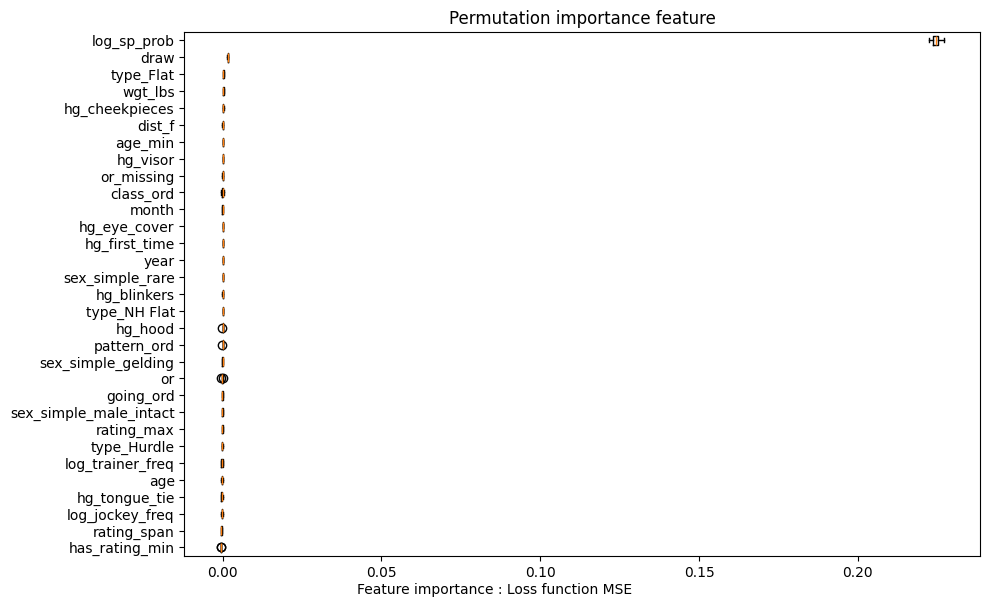

In [ ]:
perm_sorted_idx = perm_importance.importances_mean.argsort()

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))
ax1.boxplot(
    perm_importance.importances[perm_sorted_idx].T,
    vert=False,
    labels=X_train.columns[perm_sorted_idx]
)
plt.title('Permutation importance feature')
fig.text(.5, .001, "Feature importance : Loss function MSE", ha='center')

fig.tight_layout()
plt.show()

### 12.2 SHAP
Waterfall

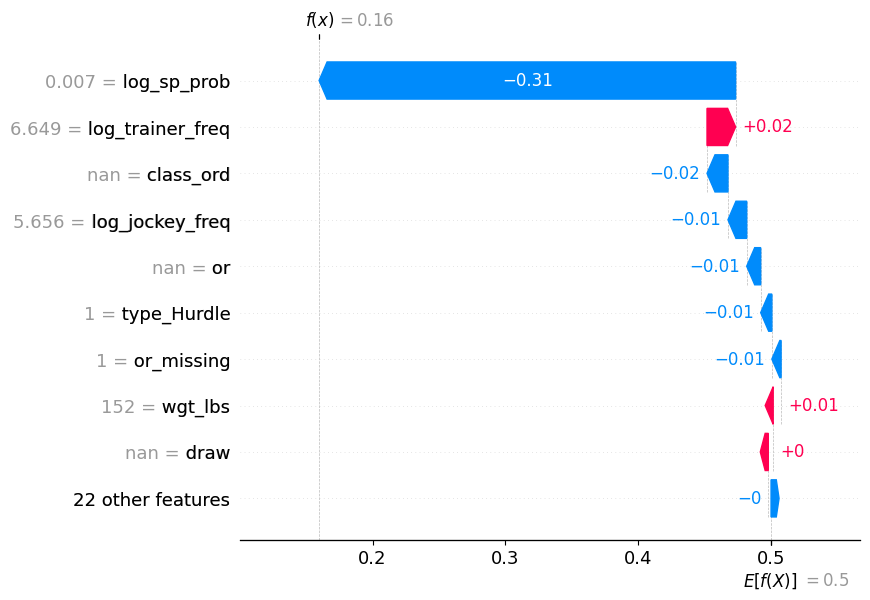

In [ ]:
import shap
import pandas as pd
import numpy as np

# Échantillon à expliquer
X_to_explain = X_test.sample(n=100, random_state=42).copy()

# Explainer
explainer = shap.TreeExplainer(rf_model)

# Calcul SHAP
shap_values = explainer(X_to_explain)

# Choix d’un individu
i = 10

# Choix de la classe 1 = top3
shap_explanation = shap.Explanation(
    values=shap_values.values[i, :, 1],          # 1 individu, toutes les variables, classe 1
    base_values=shap_values.base_values[i, 1],   # valeur de base pour cet individu et cette classe
    data=X_to_explain.iloc[i, :],
    feature_names=X_to_explain.columns
)

# Waterfall plot
shap.plots.waterfall(shap_explanation)

Beeswarm

Le beeswarm plot permet de synthétiser l’effet global des variables sur les prédictions du modèle. Contrairement à une simple mesure d’importance, il montre à la fois l’intensité de l’effet de chaque variable et son sens, c’est-à-dire si elle augmente ou diminue la probabilité prédite de terminer dans le top 3.

Ce graphique permet ainsi d’identifier les variables les plus influentes tout en visualisant l’hétérogénéité de leurs effets selon les individus.

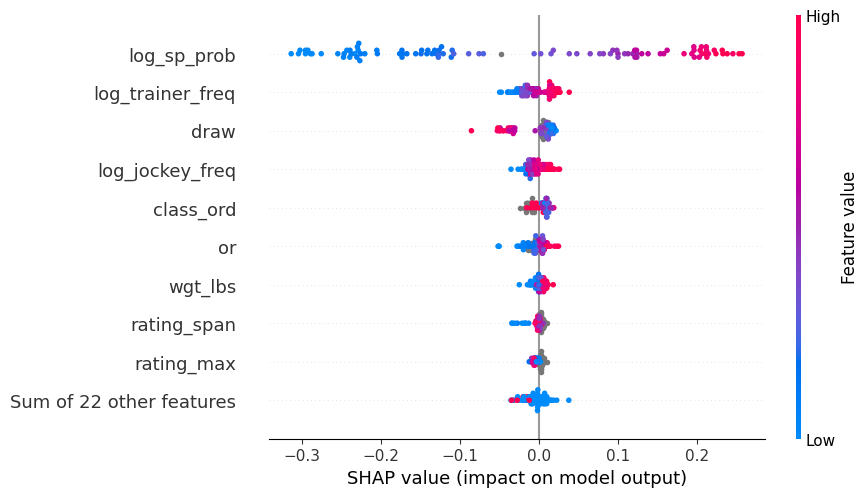

In [ ]:
shap_expl = shap.Explanation(
    values=shap_values.values[:, :, 1],         # toutes les obs, toutes les variables, classe 1
    base_values=shap_values.base_values[:, 1],  # valeur de base classe 1
    data=X_to_explain.to_numpy(),
    feature_names=X_to_explain.columns.tolist()
)

shap.plots.beeswarm(shap_expl)

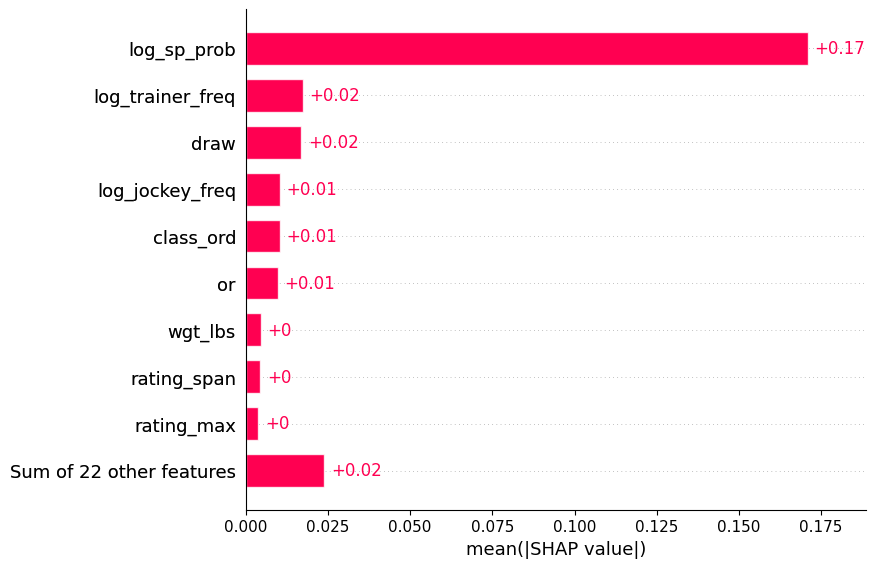

In [ ]:
shap.plots.bar(shap_expl)

**Interprétation**

Le waterfall plot permet d’expliquer la prédiction du modèle pour un individu spécifique. Dans cet exemple, la prédiction finale du modèle est relativement faible (f(x) = 0.16), indiquant une faible probabilité de terminer dans le top 3.

La variable `log_sp_prob` joue un rôle déterminant dans cette prédiction. Sa valeur très faible contribue fortement à diminuer la probabilité prédite, avec un impact négatif très marqué. Cela confirme son rôle central dans le modèle : lorsque cette variable est faible, la prédiction est fortement pénalisée.

Les autres variables ont des contributions beaucoup plus modestes. Certaines, comme `log_trainer_freq` ou `wgt_lbs`, ont un effet légèrement positif, mais insuffisant pour compenser l’impact négatif de `log_sp_prob`. D’autres variables contribuent faiblement à la baisse de la prédiction, sans jouer un rôle déterminant.



## 12.3 PDP (Partial Dependence)
uniquement les variables clées  

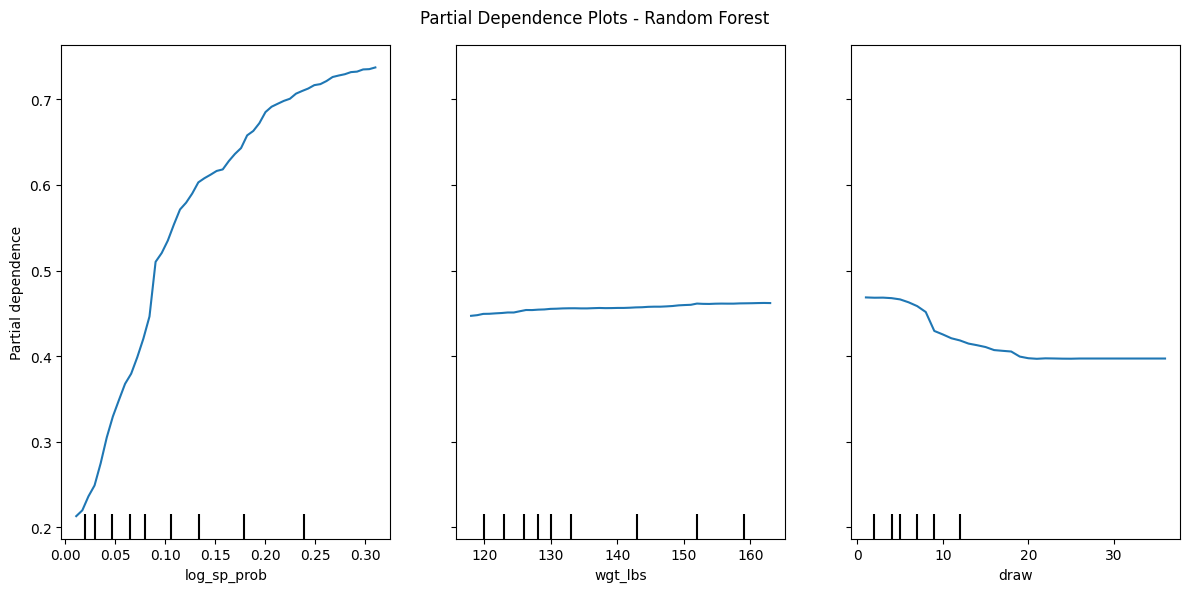

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Variables d'intérêt
features_pdp = ['log_sp_prob', 'wgt_lbs', 'draw']

fig, ax = plt.subplots(figsize=(12, 6))

PartialDependenceDisplay.from_estimator(
    rf_model,          #  modèle entraîné
    X_train,           # données d'entraînement
    features_pdp,      # variables à analyser
    kind="average",    # PDP
    grid_resolution=50,  # nombre de points pour tracer la courbe
    ax=ax
)

plt.suptitle("Partial Dependence Plots - Random Forest")
plt.tight_layout()
plt.show()

## 12.4  ALE ( Accumulated local effect)

c:\Users\33783\Desktop\M2\SVM\cours_iae\04_INTERPRETABLE_ML\.venv04\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\33783\Desktop\M2\SVM\cours_iae\04_INTERPRETABLE_ML\.venv04\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\33783\Desktop\M2\SVM\cours_iae\04_INTERPRETABLE_ML\.venv04\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\33783\Desktop\M2\SVM\cours_iae\04_INTERPRETABLE_ML\.venv04\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\33783\Desktop\M

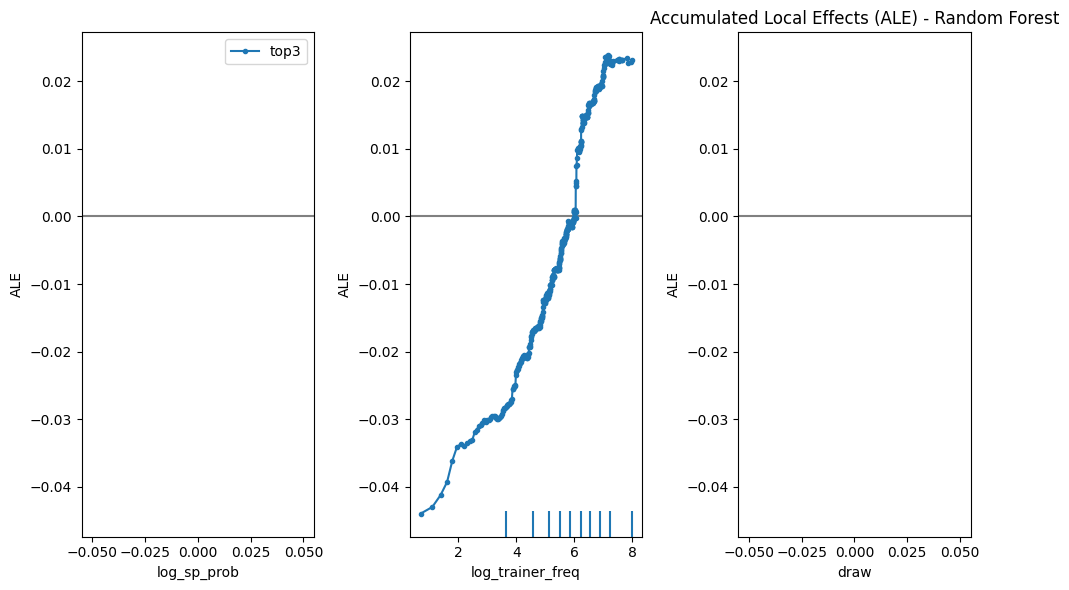

In [ ]:
from alibi.explainers import ALE, plot_ale
import matplotlib.pyplot as plt

feature_names = X_train.columns.tolist()

rf_ale = ALE(
    rf_model.predict_proba,   
    feature_names=feature_names,
    target_names=["not_top3", "top3"]
)

# calcul ale
rf_exp = rf_ale.explain(X_train.to_numpy())

# choix des 3 variables les plus importantes pour faire les plots ALE
top_ale = rf_importance.head(3)['Variable'].tolist()

fig, ax = plt.subplots(figsize=(10, 6))

plot_ale(
    rf_exp,
    features=top_ale,
    ax=ax,
    targets=[1]  # classe 1 = top3
)

plt.title("Accumulated Local Effects (ALE) - Random Forest")
plt.tight_layout()
plt.show()

## 12.5  ICE

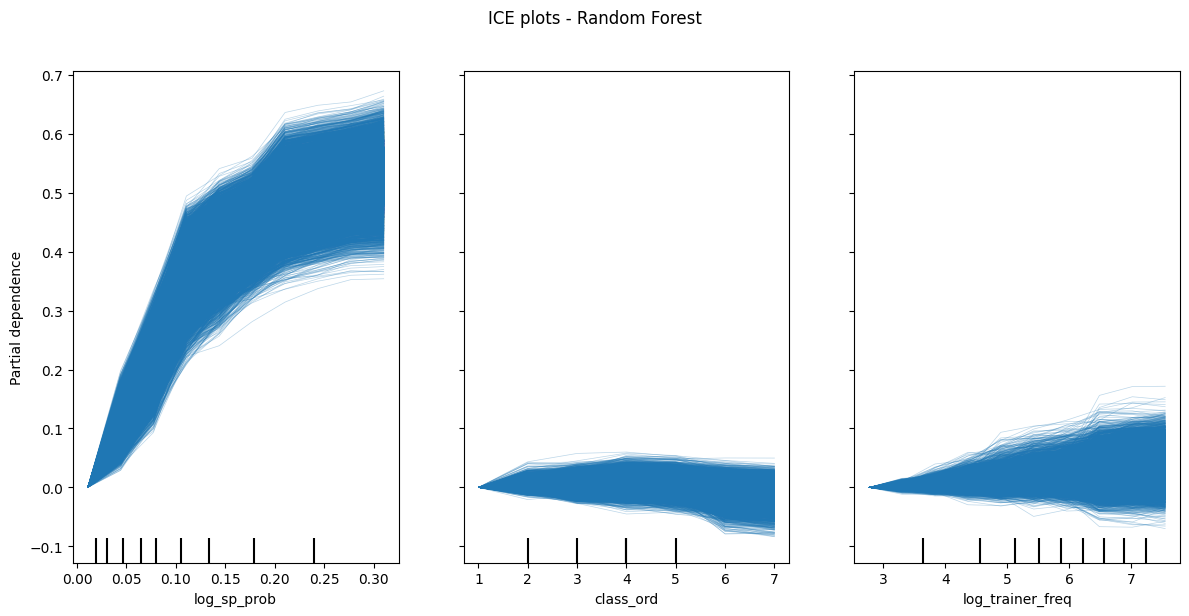

In [ ]:
features_ice = ['log_sp_prob', 'class_ord', 'log_trainer_freq']

_, ax = plt.subplots(figsize=(12, 6))

PartialDependenceDisplay.from_estimator(
    rf_model,              #  modèle entraîné
    X_train,
    features_ice,
    kind="individual",     # ICE
    ax=ax,
    grid_resolution=10, # Nombre de points estimés pour le tracer de la courbe
    n_cols=3,
    subsample=0.05, # 5% du jeu de données
     centered=True
)

plt.suptitle("ICE plots - Random Forest", y=1.02)
plt.tight_layout()
plt.show()

## 12.6 Étude des résidus et des performances du modèle

L’objectif de cette partie est d’évaluer la qualité des prédictions du modèle de Random Forest au-delà des seules métriques globales. Plutôt que d’analyser des résidus au sens classique de la régression peu pertinents dans un cadre de classification binaire. on s’intéresse ici à la capacité du modèle à discriminer correctement les observations et à produire des probabilités fiables.

Pour cela, trois outils complémentaires sont mobilisés :

- la courbe ROC, qui mesure la capacité du modèle à distinguer les classes 
- la precision recall curve, particulièrement adaptée en présence de déséquilibre des classes 
la courbe de calibration, qui évalue la qualité des probabilités prédites


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve

# Probabilités prédites pour la classe 1 = top3
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

Roc curve

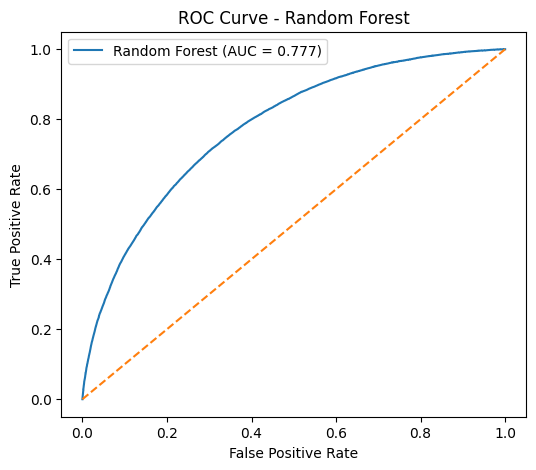

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

La courbe ROC obtenue présente une aire sous la courbe (AUC) de 0.777, ce qui indique une bonne capacité du modèle à discriminer les chevaux terminant dans le top 3 de ceux qui n’y parviennent pas.

Plus précisément, cela signifie que le modèle a environ 77,7 % de chances de classer correctement une paire aléatoire composée d’un cheval ayant terminé dans le top 3 et d’un cheval ne l’ayant pas fait.

La courbe est nettement au-dessus de la diagonale (modèle aléatoire), ce qui confirme que le modèle capture une information pertinente dans les données. Néanmoins, la courbe reste éloignée du coin supérieur gauche, ce qui indique que la discrimination est imparfaite et qu’il existe encore des erreurs de classification.

Precision-Recall Curve

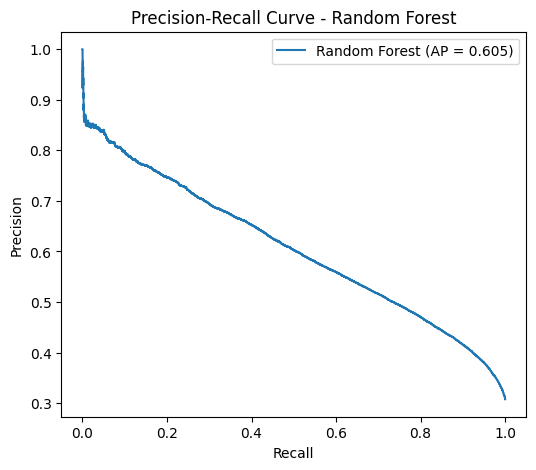

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)
ap_score = average_precision_score(y_test, y_proba_rf)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Random Forest (AP = {ap_score:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.show()

La courbe précision-rappel met en évidence un compromis entre la capacité du modèle à identifier correctement les chevaux du top 3 (rappel) et la fiabilité de ces prédictions (précision).

L’aire sous la courbe (Average Precision) est de 0.605, ce qui indique une performance correcte mais plus modérée que celle suggérée par la ROC. Cela est attendu, car cette métrique est plus exigeante en présence de classes déséquilibrées, comme ici.
Le modèle est efficace pour identifier les meilleurs chevaux avec une bonne précision, mais au prix d’une couverture plus limitée. Cela correspond bien à une logique de pari où l’on préfère sélectionner peu de chevaux mais avec un fort niveau de confiance.

Calibration Curve 

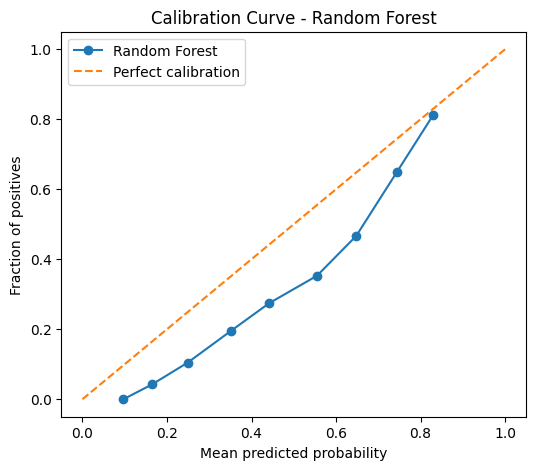

In [ ]:
prob_true, prob_pred = calibration_curve(y_test, y_proba_rf, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker='o', label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle='--', label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve - Random Forest")
plt.legend()
plt.show()

La courbe de calibration compare les probabilités prédites par le modèle à la fréquence réelle des événements.

On observe que la courbe est globalement en dessous de la diagonale, ce qui signifie que le modèle a tendance à surestimer les probabilités. Autrement dit, lorsqu’il prédit une probabilité de 0.6, la fréquence réelle observée est inférieure.

Cette mauvaise calibration est particulièrement visible pour les probabilités intermédiaires, où l’écart avec la diagonale est le plus marqué.